In [33]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
# ==============================================================================
# FILE 12: TEST SEGMENTATION ONLY - EXTERNAL DATA
# ==============================================================================
# Mục đích: Test khả năng phân đoạn (segmentation) trên ảnh external
# Đánh giá: IoU, Dice Score, Pixel Accuracy, Precision, Recall, F1
# Input:  Ảnh + Ground truth mask (nếu có)
# Output:  Metrics, visualization, confusion matrix (pixel-wise)
# ==============================================================================

import os
import json
import cv2
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from datetime import datetime
from collections import Counter

from PIL import Image

# Mount Google Drive

# ==============================================================================
# SETUP ĐƯỜNG DẪN
# ==============================================================================

GDRIVE_PATH = 'd:/DoAn_DaLieu'
DATA_TEST_PATH = os.path.join(GDRIVE_PATH, "1_Data", "Data_test")
MASKS_PATH = os.path.join(GDRIVE_PATH, "1_Data", "Data_test_masks")  # Ground truth masks (nếu có)
SEGMENTATION_TEST_PATH = os.path.join(GDRIVE_PATH, "8_Segmentation_Test")
RESULTS_FOLDER = os. path.join(SEGMENTATION_TEST_PATH, "results")
EXTERNAL_CSV = os.path.join(SEGMENTATION_TEST_PATH, "segmentation_test. csv")

os.makedirs(SEGMENTATION_TEST_PATH, exist_ok=True)
os.makedirs(RESULTS_FOLDER, exist_ok=True)

print(f"\n✅ DATA_TEST_PATH: {DATA_TEST_PATH}")
print(f"✅ MASKS_PATH: {MASKS_PATH}")
print(f"✅ RESULTS_FOLDER: {RESULTS_FOLDER}")

print("\n" + "="*80)
print("📦 FILE 12: SEGMENTATION TEST - INITIALIZED")
print("="*80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ DATA_TEST_PATH: d:/DoAn_DaLieu/1_Data/Data_test
✅ MASKS_PATH: d:/DoAn_DaLieu/1_Data/Data_test_masks
✅ RESULTS_FOLDER: d:/DoAn_DaLieu/8_Segmentation_Test/results

📦 FILE 12: SEGMENTATION TEST - INITIALIZED


In [34]:
# ==============================================================================
# LOAD PREPROCESSING UTILS
# ==============================================================================

print("\n" + "="*80)
print("📦 LOADING PREPROCESSING UTILS")
print("="*80)

checkpoint_path = os.path.join(GDRIVE_PATH, "3_Checkpoints", "10_preprocessing_utils_complete.json")

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"❌ Checkpoint not found: {checkpoint_path}")

with open(checkpoint_path, 'r', encoding='utf-8') as f:
    prep_config = json.load(f)

print(f"✅ Checkpoint loaded: {prep_config['timestamp']}")
print(f"   Version: {prep_config['version']}")


📦 LOADING PREPROCESSING UTILS
✅ Checkpoint loaded: 2025-12-16T11:01:22.991942
   Version: 1.1.0


In [35]:
# ==============================================================================
# PREPROCESSING PIPELINE CLASSES
# ==============================================================================

class PreprocessingPipeline:
    """Pipeline tiền xử lý cho ảnh da"""
    def __init__(self,
                 remove_hair=False,
                 reduce_shadow=False,
                 smooth_skin=False,
                 enhance_contrast=False,
                 clip_limit=2.0):
        self.remove_hair = remove_hair
        self.reduce_shadow = reduce_shadow
        self.smooth_skin = smooth_skin
        self.enhance_contrast = enhance_contrast
        self. clip_limit = clip_limit

    def __call__(self, image):
        debug_info = {'original':  image.copy()}
        processed = image.copy()

        if self.remove_hair:
            processed = self._remove_hair(processed)
            debug_info['after_hair_removal'] = processed.copy()

        if self.reduce_shadow:
            processed = self._reduce_shadow(processed)
            debug_info['after_shadow_reduction'] = processed.copy()

        if self.smooth_skin:
            processed = self._smooth_skin(processed)
            debug_info['after_smoothing'] = processed.copy()

        if self.enhance_contrast:
            processed = self._enhance_contrast(processed)
            debug_info['after_contrast'] = processed.copy()

        return processed, debug_info

    def _remove_hair(self, image):
        """Loại bỏ lông - kernel 13×13, threshold 12"""
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, hair_mask = cv2.threshold(blackhat, 12, 255, cv2.THRESH_BINARY)
        kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        hair_mask = cv2.morphologyEx(hair_mask, cv2.MORPH_OPEN, kernel_clean)

        hair_pixels = np.sum(hair_mask > 0)
        if hair_pixels > 300:
            result = cv2.inpaint(image, hair_mask, inpaintRadius=4, flags=cv2.INPAINT_TELEA)
            return result
        return image

    def _reduce_shadow(self, image):
        """Giảm bóng - CLAHE dynamic"""
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return result

    def _smooth_skin(self, image):
        """Làm mịn da - bilateral filter"""
        return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    def _enhance_contrast(self, image):
        """Tăng contrast - CLAHE"""
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)


print("✅ PreprocessingPipeline defined")

✅ PreprocessingPipeline defined


In [36]:
# ==============================================================================
# POSTPROCESSING PIPELINE CLASSES
# ==============================================================================

class PostprocessingPipeline:
    """Pipeline hậu xử lý cho mask"""
    def __init__(self,
                 fill_holes=True,
                 remove_small_objects=True,
                 smooth_boundary=True,
                 select_largest=True,
                 min_object_size=500,
                 smart_mode=True,
                 distance_threshold=30):
        self.fill_holes = fill_holes
        self. remove_small_objects = remove_small_objects
        self.smooth_boundary = smooth_boundary
        self.select_largest = select_largest
        self.min_object_size = min_object_size
        self.smart_mode = smart_mode
        self.distance_threshold = distance_threshold

    def __call__(self, mask_pred, threshold=0.5):
        debug_info = {'original': mask_pred.copy(), 'warnings': []}
        mask_binary = (mask_pred > threshold).astype(np.uint8) * 255
        processed = mask_binary.copy()

        if self.fill_holes:
            processed = self._fill_holes(processed)

        if self.remove_small_objects:
            if self.smart_mode:
                processed, warnings_remove = self._remove_small_smart(processed, self.min_object_size)
                debug_info['warnings'].extend(warnings_remove)
            else:
                processed = self._remove_small(processed, self.min_object_size)

        if self.smooth_boundary:
            processed = self._smooth_boundary(processed)

        if self.select_largest:
            if self.smart_mode:
                processed, best_contour, warnings_select = self._select_largest_smart(processed)
                debug_info['warnings'].extend(warnings_select)
                debug_info['best_contour'] = best_contour
            else:
                processed, best_contour = self._select_largest(processed)
                debug_info['best_contour'] = best_contour

        return processed, debug_info

    def _fill_holes(self, mask):
        """Lấp lỗ hổng trong mask"""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
        closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        h, w = closed.shape
        mask_flood = closed.copy()
        cv2.floodFill(mask_flood, None, (0, 0), 255)
        mask_flood_inv = cv2.bitwise_not(mask_flood)
        return closed | mask_flood_inv

    def _remove_small(self, mask, min_size):
        """Loại bỏ vùng nhỏ - basic"""
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        cleaned = np.zeros_like(mask)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= min_size:
                cleaned[labels == i] = 255
        return cleaned

    def _remove_small_smart(self, mask, min_size, min_solidity=0.7):
        """Loại bỏ vùng nhỏ - smart (giữ vùng compact)"""
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        mask_cleaned = np.zeros_like(mask)
        warnings = []
        removed_count = 0
        kept_small_count = 0

        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]

            if area >= min_size:
                mask_cleaned[labels == i] = 255
                continue

            component_mask = (labels == i).astype(np.uint8) * 255
            contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if len(contours) > 0:
                cnt = contours[0]
                hull = cv2.convexHull(cnt)
                hull_area = cv2.contourArea(hull)

                if hull_area > 0:
                    solidity = area / hull_area
                    solidity = min(solidity, 1.0)
                else:
                    solidity = 0.0

                if solidity >= min_solidity:
                    mask_cleaned[labels == i] = 255
                    kept_small_count += 1
                    if area > 300:
                        warnings.append(f"Kept small region ({area}px, solidity={solidity:.2f})")
                else:
                    removed_count += 1

        if removed_count > 0:
            warnings.append(f"Removed {removed_count} small regions")

        if kept_small_count > 0:
            warnings.append(f"⚠️ Kept {kept_small_count} compact regions")

        return mask_cleaned, warnings

    def _smooth_boundary(self, mask):
        """Làm mịn biên"""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        smoothed = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        smoothed = cv2.morphologyEx(smoothed, cv2.MORPH_CLOSE, kernel)
        return smoothed

    def _select_largest(self, mask):
        """Chọn vùng lớn nhất - basic"""
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            return mask, None

        contour_features = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < self.min_object_size:
                continue
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area > 0 else 0
            score = area * (0.8 + 0.2 * solidity)
            contour_features.append({'contour': cnt, 'score': score})

        if not contour_features:
            return mask, None

        best = max(contour_features, key=lambda x: x['score'])
        mask_largest = np.zeros_like(mask)
        cv2.drawContours(mask_largest, [best['contour']], -1, 255, -1)
        return mask_largest, best['contour']

    def _select_largest_smart(self, mask):
        """Chọn vùng lớn nhất - smart (phát hiện multiple lesions)"""
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        warnings = []

        if len(contours) == 0:
            return mask, None, warnings

        if len(contours) == 1:
            return mask, contours[0], warnings

        contour_data = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < self.min_object_size:
                continue

            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area > 0 else 0
            score = area * (0.8 + 0.2 * solidity)

            M = cv2.moments(cnt)
            if M['m00'] != 0:
                cx = int(M['m10'] / M['m00'])
                cy = int(M['m01'] / M['m00'])
            else:
                cx, cy = 0, 0

            contour_data.append({
                'contour': cnt,
                'area': area,
                'score':  score,
                'centroid': (cx, cy)
            })

        if not contour_data:
            return mask, None, warnings

        contour_data = sorted(contour_data, key=lambda x: x['score'], reverse=True)
        top1 = contour_data[0]
        top2 = contour_data[1] if len(contour_data) > 1 else None

        if top2 is not None:
            dist = np.sqrt((top1['centroid'][0] - top2['centroid'][0])**2 +
                           (top1['centroid'][1] - top2['centroid'][1])**2)
            area_ratio = top2['area'] / top1['area']

            if dist > self.distance_threshold and area_ratio > 0.3:
                warnings.append(f"MULTIPLE_LESIONS: dist={dist:.0f}px, ratio={area_ratio:.2f}")

        mask_largest = np.zeros_like(mask)
        cv2.drawContours(mask_largest, [top1['contour']], -1, 255, -1)
        return mask_largest, top1['contour'], warnings


print("✅ PostprocessingPipeline defined")

✅ PostprocessingPipeline defined


In [37]:
# ==============================================================================
# PRESET HELPERS
# ==============================================================================

PREPROCESSING_PRESETS = prep_config['preprocessing']['presets']
POSTPROCESSING_PRESETS = prep_config['postprocessing']['presets']

def get_preprocessing_preset(preset_name):
    """Tạo PreprocessingPipeline từ preset name"""
    if preset_name not in PREPROCESSING_PRESETS:
        raise ValueError(f"Unknown preset: {preset_name}. Available: {list(PREPROCESSING_PRESETS.keys())}")
    return PreprocessingPipeline(**PREPROCESSING_PRESETS[preset_name]['config'])

def get_postprocessing_preset(preset_name):
    """Tạo PostprocessingPipeline từ preset name"""
    if preset_name not in POSTPROCESSING_PRESETS:
        raise ValueError(f"Unknown preset: {preset_name}. Available: {list(POSTPROCESSING_PRESETS. keys())}")
    return PostprocessingPipeline(**POSTPROCESSING_PRESETS[preset_name]['config'])

print("✅ Preset helpers defined")
print(f"   - Preprocessing presets: {list(PREPROCESSING_PRESETS.keys())}")
print(f"   - Postprocessing presets: {list(POSTPROCESSING_PRESETS.keys())}")

✅ Preset helpers defined
   - Preprocessing presets: ['smartphone', 'smartphone_light', 'elderly_skin', 'clinic', 'clean']
   - Postprocessing presets: ['noisy', 'clean']


In [38]:
!pip install segmentation_models_pytorch
!pip install matplotlib seaborn sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [39]:
# ==============================================================================
# LOAD SEGMENTATION MODELS
# ==============================================================================

print("\n" + "="*80)
print("📦 LOADING SEGMENTATION MODELS")
print("="*80)

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, "3_Checkpoints")

# ==============================================================================
# Load U-Net
# ==============================================================================
with open(os.path.join(CHECKPOINT_PATH, "02_unet_complete.json"), 'r') as f:
    unet_checkpoint = json.load(f)

unet_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)
unet_model.load_state_dict(
    torch.load(unet_checkpoint['paths']['best_model'], map_location=device)['model_state_dict']
)
unet_model = unet_model.to(device).eval()
print("✅ U-Net loaded")

# ==============================================================================
# Load DeepLabV3+
# ==============================================================================
with open(os.path.join(CHECKPOINT_PATH, "03_deeplabv3plus_complete.json"), 'r') as f:
    deeplab_checkpoint = json.load(f)

deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)
deeplab_model.load_state_dict(
    torch.load(deeplab_checkpoint['paths']['best_model'], map_location=device)['model_state_dict']
)
deeplab_model = deeplab_model.to(device).eval()
print("✅ DeepLabV3+ loaded")

# ==============================================================================
# Hybrid Model
# ==============================================================================
class HybridSegmentation(nn.Module):
    def __init__(self, unet, deeplab, method='max'):
        super().__init__()
        self.unet = unet
        self.deeplab = deeplab
        self.method = method

    def forward(self, x):
        with torch.no_grad():
            pred_unet = torch.sigmoid(self.unet(x))
            pred_deeplab = torch.sigmoid(self.deeplab(x))
            return torch.max(pred_unet, pred_deeplab)

hybrid_model = HybridSegmentation(unet_model, deeplab_model, method='max').eval()
print("✅ Hybrid model created")

print("\n" + "="*80)
print("✅ ALL MODELS LOADED")
print("="*80)


📦 LOADING SEGMENTATION MODELS
🖥️ Device: cpu
✅ U-Net loaded
✅ DeepLabV3+ loaded
✅ Hybrid model created

✅ ALL MODELS LOADED


In [40]:
# ==============================================================================
# SEGMENTATION METRICS FUNCTIONS
# ==============================================================================

def calculate_iou(pred_mask, gt_mask, threshold=0.5):
    """
    Tính IoU (Intersection over Union)

    Args:
        pred_mask: Predicted mask (H, W) in [0, 1]
        gt_mask: Ground truth mask (H, W) in [0, 1]
        threshold: Threshold to binarize masks

    Returns:
        iou: float
    """
    pred_binary = (pred_mask > threshold).astype(np.uint8)
    gt_binary = (gt_mask > threshold).astype(np.uint8)

    intersection = np.logical_and(pred_binary, gt_binary).sum()
    union = np.logical_or(pred_binary, gt_binary).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    iou = intersection / union
    return iou


def calculate_dice(pred_mask, gt_mask, threshold=0.5):
    """
    Tính Dice Score (F1 Score for segmentation)

    Args:
        pred_mask:  Predicted mask (H, W) in [0, 1]
        gt_mask: Ground truth mask (H, W) in [0, 1]
        threshold:  Threshold to binarize masks

    Returns:
        dice:  float
    """
    pred_binary = (pred_mask > threshold).astype(np.uint8)
    gt_binary = (gt_mask > threshold).astype(np.uint8)

    intersection = np.logical_and(pred_binary, gt_binary).sum()

    if pred_binary.sum() + gt_binary.sum() == 0:
        return 1.0 if intersection == 0 else 0.0

    dice = 2 * intersection / (pred_binary.sum() + gt_binary.sum())
    return dice


def calculate_pixel_accuracy(pred_mask, gt_mask, threshold=0.5):
    """
    Tính Pixel Accuracy

    Args:
        pred_mask: Predicted mask (H, W) in [0, 1]
        gt_mask:  Ground truth mask (H, W) in [0, 1]
        threshold: Threshold to binarize masks

    Returns:
        accuracy: float
    """
    pred_binary = (pred_mask > threshold).astype(np.uint8)
    gt_binary = (gt_mask > threshold).astype(np.uint8)

    correct = (pred_binary == gt_binary).sum()
    total = pred_binary.size

    accuracy = correct / total
    return accuracy


def calculate_precision_recall_f1(pred_mask, gt_mask, threshold=0.5):
    """
    Tính Precision, Recall, F1 cho segmentation

    Args:
        pred_mask: Predicted mask (H, W) in [0, 1]
        gt_mask: Ground truth mask (H, W) in [0, 1]
        threshold: Threshold to binarize masks

    Returns:
        dict: {'precision': float, 'recall':  float, 'f1': float}
    """
    pred_binary = (pred_mask > threshold).astype(np.uint8)
    gt_binary = (gt_mask > threshold).astype(np.uint8)

    tp = np.logical_and(pred_binary == 1, gt_binary == 1).sum()
    fp = np.logical_and(pred_binary == 1, gt_binary == 0).sum()
    fn = np.logical_and(pred_binary == 0, gt_binary == 1).sum()
    tn = np.logical_and(pred_binary == 0, gt_binary == 0).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn)
    }


print("✅ Segmentation metrics functions defined")
print("   - IoU (Intersection over Union)")
print("   - Dice Score")
print("   - Pixel Accuracy")
print("   - Precision, Recall, F1")

✅ Segmentation metrics functions defined
   - IoU (Intersection over Union)
   - Dice Score
   - Pixel Accuracy
   - Precision, Recall, F1


In [41]:
# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def preprocess_for_segmentation(image):
    """
    Tiền xử lý ảnh cho segmentation model

    Args:
        image: RGB numpy array

    Returns:
        tensor: (1, 3, 256, 256)
    """
    img = cv2.resize(image, (256, 256)).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std
    return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()


def load_ground_truth_mask(image_name, masks_folder):
    """
    Load ground truth mask (nếu có)

    Args:
        image_name:  Tên file ảnh (vd: 'image. jpg')
        masks_folder:  Đường dẫn folder chứa masks

    Returns:
        mask: numpy array (H, W) in [0, 1] hoặc None nếu không tìm thấy
    """
    if masks_folder is None or not os.path.exists(masks_folder):
        return None

    # Thử các extension mask
    base_name = os.path.splitext(image_name)[0]
    mask_extensions = ['_mask.png', '_segmentation.png', '.png', '_mask.jpg', '. jpg']

    for ext in mask_extensions:
        mask_path = os.path.join(masks_folder, base_name + ext)
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                # Normalize to [0, 1]
                mask = mask. astype(np.float32) / 255.0
                return mask

    return None


def remove_small_regions(mask, min_size=500):
    """
    Loại bỏ các vùng nhỏ trong mask

    Args:
        mask: Binary mask (0 và 255)
        min_size: Ngưỡng diện tích tối thiểu

    Returns:
        mask:  Mask đã được làm sạch
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned_mask = np.zeros_like(mask)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            cleaned_mask[labels == i] = 255

    return cleaned_mask


print("✅ Helper functions defined")

✅ Helper functions defined


In [42]:
# ==============================================================================
# PREDICT SEGMENTATION SINGLE IMAGE
# ==============================================================================

def predict_segmentation_single_image(image_path,
                                     gt_mask_path=None,
                                     model=None,
                                     apply_preprocessing=False,
                                     preprocessing_preset='none',
                                     apply_postprocessing=True,
                                     postprocessing_preset='noisy',
                                     save_visualization=True,
                                     debug=False):
    """
    Dự đoán segmentation cho 1 ảnh

    Args:
        image_path: Đường dẫn ảnh
        gt_mask_path: Đường dẫn ground truth mask (optional)
        model: Segmentation model (default: hybrid_model)
        apply_preprocessing: Có áp dụng preprocessing không
        preprocessing_preset: Preset preprocessing
        apply_postprocessing: Có áp dụng postprocessing không
        postprocessing_preset: Preset postprocessing
        save_visualization:  Lưu visualization
        debug: Debug mode

    Returns:
        results: Dictionary chứa kết quả
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Cannot load:  {image_path}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_size = image_rgb.shape[:2]

    if debug:
        print(f"\n{'='*80}")
        print(f"📸 SEGMENTATION TEST:  {os.path.basename(image_path)}")
        print(f"   Size: {original_size[1]}x{original_size[0]}")
        print(f"{'='*80}")

    # Preprocessing
    if apply_preprocessing and preprocessing_preset != 'none':
        if debug:
            print(f"\n🔧 Applying preprocessing:  {preprocessing_preset}")
        preprocess = get_preprocessing_preset(preprocessing_preset)
        image_processed, _ = preprocess(image_rgb)
    else:
        image_processed = image_rgb. copy()

    # Segmentation inference
    if debug:
        print(f"\n🔬 Running segmentation inference...")

    if model is None:
        model = hybrid_model

    img_tensor = preprocess_for_segmentation(image_processed).to(device)

    with torch. no_grad():
        mask_pred = model(img_tensor).squeeze().cpu().numpy()

    # Resize về kích thước gốc
    mask_resized = cv2.resize(mask_pred, (original_size[1], original_size[0]))

    # Postprocessing
    if apply_postprocessing:
        if debug:
            print(f"\n🔧 Applying postprocessing: {postprocessing_preset}")
        postprocess = get_postprocessing_preset(postprocessing_preset)

        # Convert to uint8 [0, 255]
        mask_binary = (mask_resized > 0.5).astype(np.uint8) * 255

        # Remove small regions
        mask_cleaned = remove_small_regions(mask_binary, min_size=500)

        # Apply postprocessing
        mask_final, post_debug = postprocess(mask_cleaned, threshold=0.5)

        # Convert back to [0, 1]
        mask_final_01 = mask_final.astype(np. float32) / 255.0

        post_warnings = post_debug.get('warnings', [])
    else:
        mask_final_01 = np.clip(mask_resized, 0, 1)
        post_warnings = []

    # Load ground truth mask (nếu có)
    has_gt = False
    metrics = {}
    gt_mask = None

    if gt_mask_path is not None and os.path.exists(gt_mask_path):
        if debug:
            print(f"\n📊 Loading ground truth mask...")
        gt_mask = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)

        if gt_mask is not None:
            # Resize về kích thước gốc
            gt_mask = cv2.resize(gt_mask, (original_size[1], original_size[0]))
            gt_mask = gt_mask. astype(np.float32) / 255.0
            has_gt = True

            # Calculate metrics
            if debug:
                print(f"\n📊 Calculating metrics...")
            metrics['iou'] = calculate_iou(mask_final_01, gt_mask)
            metrics['dice'] = calculate_dice(mask_final_01, gt_mask)
            metrics['pixel_accuracy'] = calculate_pixel_accuracy(mask_final_01, gt_mask)

            prf = calculate_precision_recall_f1(mask_final_01, gt_mask)
            metrics. update(prf)

            if debug:
                print(f"   IoU: {metrics['iou']:.4f}")
                print(f"   Dice: {metrics['dice']:.4f}")
                print(f"   Pixel Accuracy: {metrics['pixel_accuracy']:.4f}")
                print(f"   Precision:  {metrics['precision']:.4f}")
                print(f"   Recall: {metrics['recall']:.4f}")
                print(f"   F1: {metrics['f1']:.4f}")

    # Visualization
    if save_visualization or debug:
        if has_gt:
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        else:
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            axes = np.array([axes])  # Make it 2D for consistency

        # Row 1: Original, Predicted Mask, Overlay
        axes[0][0].imshow(image_rgb)
        axes[0][0].set_title('Original Image', fontsize=14, fontweight='bold')
        axes[0][0].axis('off')

        axes[0][1].imshow(mask_final_01, cmap='hot')
        axes[0][1].set_title('Predicted Mask', fontsize=14, fontweight='bold')
        axes[0][1].axis('off')

        overlay = image_rgb.copy()
        mask_colored = cv2.applyColorMap(np.uint8(255 * mask_final_01), cv2.COLORMAP_JET)
        mask_colored = cv2.cvtColor(mask_colored, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(overlay, 0.6, mask_colored, 0.4, 0)
        axes[0][2].imshow(overlay)
        axes[0][2].set_title('Overlay', fontsize=14, fontweight='bold')
        axes[0][2].axis('off')

        # Row 2: GT mask, Difference, Metrics (if GT available)
        if has_gt:
            axes[1][0]. imshow(gt_mask, cmap='hot')
            axes[1][0].set_title('Ground Truth Mask', fontsize=14, fontweight='bold')
            axes[1][0].axis('off')

            # Difference map
            diff = np.abs(mask_final_01 - gt_mask)
            axes[1][1].imshow(diff, cmap='RdYlGn_r')
            axes[1][1].set_title('Difference Map', fontsize=14, fontweight='bold')
            axes[1][1].axis('off')

            # Metrics text
            axes[1][2].axis('off')
            metrics_text = f"""
SEGMENTATION METRICS
{'='*35}

IoU:               {metrics['iou']:.4f}
Dice Score:       {metrics['dice']:.4f}
Pixel Accuracy:   {metrics['pixel_accuracy']:. 4f}

Precision:        {metrics['precision']:.4f}
Recall:           {metrics['recall']:.4f}
F1 Score:         {metrics['f1']:.4f}

CONFUSION MATRIX (Pixels)
{'='*35}
TP:  {metrics['tp']: ,}
FP: {metrics['fp']:,}
FN:  {metrics['fn']:,}
TN: {metrics['tn']:,}

SETTINGS
{'='*35}
Preprocessing:  {preprocessing_preset}
Postprocessing: {postprocessing_preset}
            """
            axes[1][2].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
                           verticalalignment='center',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout()

        if save_visualization:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            img_basename = os.path.splitext(os.path.basename(image_path))[0]
            save_path = os.path.join(RESULTS_FOLDER, f'seg_{img_basename}_{timestamp}.png')
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            if debug:
                print(f"\n✅ Visualization saved:  {save_path}")

        if debug:
            plt.show()
        else:
            plt.close()

    # Results
    results = {
        'image_path': image_path,
        'image_name': os.path.basename(image_path),
        'has_ground_truth': has_gt,
        'preprocessing':  preprocessing_preset,
        'postprocessing': postprocessing_preset,
        'postprocessing_warnings': post_warnings,
        'timestamp': datetime.now().isoformat()
    }

    if has_gt:
        results['metrics'] = metrics

    return results


print("✅ predict_segmentation_single_image defined")

✅ predict_segmentation_single_image defined


In [43]:
# ==============================================================================
# BATCH TEST SEGMENTATION
# ==============================================================================

def batch_test_segmentation(csv_path,
                            data_path,
                            masks_path=None,
                            model=None,
                            apply_preprocessing=False,
                            preprocessing_preset='none',
                            apply_postprocessing=True,
                            postprocessing_preset='noisy',
                            save_individual=False):
    """
    Test segmentation trên batch images

    Args:
        csv_path: Đường dẫn CSV chứa danh sách ảnh
        data_path:  Đường dẫn folder chứa ảnh
        masks_path:  Đường dẫn folder chứa ground truth masks (optional)
        model: Segmentation model
        apply_preprocessing: Áp dụng preprocessing
        preprocessing_preset: Preset preprocessing
        apply_postprocessing: Áp dụng postprocessing
        postprocessing_preset:  Preset postprocessing
        save_individual: Lưu visualization cho từng ảnh

    Returns:
        results_df: DataFrame chứa kết quả
    """
    if not os.path.exists(csv_path):
        print(f"❌ CSV not found: {csv_path}")
        return None

    df = pd.read_csv(csv_path)

    print(f"\n{'='*80}")
    print(f"🔬 BATCH SEGMENTATION TEST")
    print(f"{'='*80}")
    print(f"   Total images: {len(df)}")
    print(f"   Preprocessing: {preprocessing_preset}")
    print(f"   Postprocessing: {postprocessing_preset}")
    print(f"   Save individual:  {save_individual}")

    if model is None:
        model = hybrid_model

    all_results = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Testing Segmentation"):
        img_name = row['image_name']
        ground_truth = row. get('ground_truth', 'UNKNOWN')

        # Đường dẫn ảnh
        if 'ground_truth' in row and ground_truth != 'UNKNOWN':
            img_path = os. path.join(data_path, ground_truth, img_name)
        else:
            img_path = os.path.join(data_path, img_name)

        if not os.path.exists(img_path):
            print(f"\n⚠️ Image not found: {img_path}")
            continue

        # Đường dẫn ground truth mask (nếu có)
        gt_mask_path = None
        if masks_path is not None:
            base_name = os.path.splitext(img_name)[0]
            # Thử tìm mask với các extension khác nhau
            for ext in ['_mask.png', '_segmentation.png', '.png', '_mask. jpg', '.jpg']:
                potential_path = os.path.join(masks_path, base_name + ext)
                if os.path. exists(potential_path):
                    gt_mask_path = potential_path
                    break

        try:
            result = predict_segmentation_single_image(
                image_path=img_path,
                gt_mask_path=gt_mask_path,
                model=model,
                apply_preprocessing=apply_preprocessing,
                preprocessing_preset=preprocessing_preset,
                apply_postprocessing=apply_postprocessing,
                postprocessing_preset=postprocessing_preset,
                save_visualization=save_individual,
                debug=False
            )

            result['ground_truth'] = ground_truth
            all_results.append(result)

        except Exception as e:
            print(f"\n❌ Error processing {img_name}: {e}")
            all_results.append({
                'image_name': img_name,
                'ground_truth': ground_truth,
                'error': str(e)
            })

    # Create DataFrame
    results_df = pd. DataFrame(all_results)

    # Save results
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_csv = os.path.join(RESULTS_FOLDER, f"segmentation_results_{timestamp}.csv")

    # Flatten metrics column
    if 'metrics' in results_df.columns:
        metrics_df = pd.json_normalize(results_df['metrics'])
        metrics_df.columns = ['metric_' + col for col in metrics_df.columns]
        results_df = pd.concat([results_df. drop('metrics', axis=1), metrics_df], axis=1)

    results_df.to_csv(output_csv, index=False)
    print(f"\n✅ Results saved:  {output_csv}")

    return results_df


print("✅ batch_test_segmentation defined")

✅ batch_test_segmentation defined


In [44]:
# ==============================================================================
# SUMMARY ANALYSIS FUNCTION
# ==============================================================================

def analyze_segmentation_results(results_df):
    """
    Phân tích kết quả segmentation

    Args:
        results_df: DataFrame chứa kết quả từ batch_test_segmentation
    """
    print(f"\n{'='*80}")
    print(f"📊 SEGMENTATION RESULTS ANALYSIS")
    print(f"{'='*80}")

    # Filter valid results
    valid_results = results_df[results_df['has_ground_truth'] == True]

    if len(valid_results) == 0:
        print(f"\n⚠️ No ground truth masks found!")
        print(f"   Total predictions: {len(results_df)}")
        print(f"   Can only generate predicted masks without metrics")
        return

    print(f"\n✅ Images with ground truth: {len(valid_results)}/{len(results_df)}")

    # ==============================================================================
    # OVERALL METRICS
    # ==============================================================================
    print(f"\n{'='*80}")
    print(f"📊 OVERALL METRICS")
    print(f"{'='*80}")

    avg_iou = valid_results['metric_iou'].mean()
    avg_dice = valid_results['metric_dice'].mean()
    avg_pixel_acc = valid_results['metric_pixel_accuracy'].mean()
    avg_precision = valid_results['metric_precision'].mean()
    avg_recall = valid_results['metric_recall'].mean()
    avg_f1 = valid_results['metric_f1'].mean()

    print(f"\n   IoU:               {avg_iou:.4f}")
    print(f"   Dice Score:       {avg_dice:.4f}")
    print(f"   Pixel Accuracy:   {avg_pixel_acc:.4f}")
    print(f"   Precision:        {avg_precision:.4f}")
    print(f"   Recall:           {avg_recall:. 4f}")
    print(f"   F1 Score:         {avg_f1:.4f}")

    # ==============================================================================
    # PER-CLASS METRICS
    # ==============================================================================
    if 'ground_truth' in valid_results. columns:
        print(f"\n{'='*80}")
        print(f"📊 PER-CLASS METRICS")
        print(f"{'='*80}")

        for cls in sorted(valid_results['ground_truth'].unique()):
            cls_df = valid_results[valid_results['ground_truth'] == cls]
            if len(cls_df) > 0:
                cls_iou = cls_df['metric_iou'].mean()
                cls_dice = cls_df['metric_dice'].mean()
                cls_pixel_acc = cls_df['metric_pixel_accuracy'].mean()

                print(f"\n   {cls}:")
                print(f"      Count: {len(cls_df)}")
                print(f"      IoU:   {cls_iou:.4f}")
                print(f"      Dice:  {cls_dice:.4f}")
                print(f"      Pixel Acc: {cls_pixel_acc:. 4f}")

    # ==============================================================================
    # PIXEL-WISE CONFUSION MATRIX
    # ==============================================================================
    print(f"\n{'='*80}")
    print(f"📊 PIXEL-WISE CONFUSION MATRIX (TOTAL)")
    print(f"{'='*80}")

    total_tp = valid_results['metric_tp'].sum()
    total_fp = valid_results['metric_fp'].sum()
    total_fn = valid_results['metric_fn'].sum()
    total_tn = valid_results['metric_tn'].sum()

    print(f"\n   True Positive (TP):  {total_tp:,}")
    print(f"   False Positive (FP): {total_fp:,}")
    print(f"   False Negative (FN): {total_fn:,}")
    print(f"   True Negative (TN):  {total_tn:,}")

    # Calculate overall from total
    total_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    total_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    total_f1 = 2 * total_precision * total_recall / (total_precision + total_recall) if (total_precision + total_recall) > 0 else 0

    print(f"\n   Aggregated Metrics:")
    print(f"      Precision:  {total_precision:.4f}")
    print(f"      Recall:     {total_recall:.4f}")
    print(f"      F1:        {total_f1:.4f}")

    # ==============================================================================
    # QUALITY DISTRIBUTION
    # ==============================================================================
    print(f"\n{'='*80}")
    print(f"📊 QUALITY DISTRIBUTION")
    print(f"{'='*80}")

    # IoU distribution
    excellent = len(valid_results[valid_results['metric_iou'] >= 0.8])
    good = len(valid_results[(valid_results['metric_iou'] >= 0.6) & (valid_results['metric_iou'] < 0.8)])
    fair = len(valid_results[(valid_results['metric_iou'] >= 0.4) & (valid_results['metric_iou'] < 0.6)])
    poor = len(valid_results[valid_results['metric_iou'] < 0.4])

    print(f"\n   IoU Distribution:")
    print(f"      Excellent (≥0.8): {excellent:3d} ({excellent/len(valid_results)*100:5.1f}%)")
    print(f"      Good (0.6-0.8):   {good:3d} ({good/len(valid_results)*100:5.1f}%)")
    print(f"      Fair (0.4-0.6):   {fair:3d} ({fair/len(valid_results)*100:5.1f}%)")
    print(f"      Poor (<0.4):      {poor:3d} ({poor/len(valid_results)*100:5.1f}%)")

    # ==============================================================================
    # WORST CASES
    # ==============================================================================
    print(f"\n{'='*80}")
    print(f"📊 WORST 5 CASES (Lowest IoU)")
    print(f"{'='*80}")

    worst_cases = valid_results. nsmallest(5, 'metric_iou')[['image_name', 'ground_truth', 'metric_iou', 'metric_dice']]
    print(worst_cases.to_string(index=False))

    # ==============================================================================
    # BEST CASES
    # ==============================================================================
    print(f"\n{'='*80}")
    print(f"📊 BEST 5 CASES (Highest IoU)")
    print(f"{'='*80}")

    best_cases = valid_results.nlargest(5, 'metric_iou')[['image_name', 'ground_truth', 'metric_iou', 'metric_dice']]
    print(best_cases.to_string(index=False))

    # ==============================================================================
    # FINAL ASSESSMENT
    # ==============================================================================
    print(f"\n{'='*80}")
    print(f"🎯 FINAL ASSESSMENT")
    print(f"{'='*80}")

    if avg_iou >= 0.7 and avg_dice >= 0.8:
        print(f"\n✅ EXCELLENT SEGMENTATION")
        print(f"   → Model performs very well")
        print(f"   → Ready for deployment")
    elif avg_iou >= 0.5 and avg_dice >= 0.65:
        print(f"\n⚠️ GOOD SEGMENTATION")
        print(f"   → Model performs acceptably")
        print(f"   → Consider fine-tuning on difficult cases")
    elif avg_iou >= 0.3 and avg_dice >= 0.45:
        print(f"\n⚠️ FAIR SEGMENTATION")
        print(f"   → Model needs improvement")
        print(f"   → Check preprocessing and postprocessing strategies")
    else:
        print(f"\n❌ POOR SEGMENTATION")
        print(f"   → Model has significant issues")
        print(f"   → Consider retraining or adjusting architecture")

    print(f"\n{'='*80}")


print("✅ analyze_segmentation_results defined")

✅ analyze_segmentation_results defined


In [45]:
# ==============================================================================
# VISUALIZATION FUNCTIONS
# ==============================================================================

def plot_metrics_distribution(results_df, save_path=None):
    """
    Vẽ phân bố các metrics

    Args:
        results_df: DataFrame chứa kết quả
        save_path: Đường dẫn lưu figure
    """
    valid_results = results_df[results_df['has_ground_truth'] == True]

    if len(valid_results) == 0:
        print("❌ No ground truth available for visualization")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [
        ('metric_iou', 'IoU (Intersection over Union)'),
        ('metric_dice', 'Dice Score'),
        ('metric_pixel_accuracy', 'Pixel Accuracy'),
        ('metric_precision', 'Precision'),
        ('metric_recall', 'Recall'),
        ('metric_f1', 'F1 Score')
    ]

    for idx, (metric, title) in enumerate(metrics):
        row = idx // 3
        col = idx % 3

        axes[row, col].hist(valid_results[metric], bins=20, color='steelblue',
                           edgecolor='black', alpha=0.7)
        axes[row, col]. set_title(title, fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('Score', fontsize=10)
        axes[row, col].set_ylabel('Frequency', fontsize=10)

        mean_val = valid_results[metric].mean()
        axes[row, col].axvline(mean_val, color='red', linestyle='--',
                              linewidth=2, label=f'Mean: {mean_val:.3f}')
        axes[row, col].legend(fontsize=9)
        axes[row, col].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is None:
        save_path = os.path.join(RESULTS_FOLDER, 'metrics_distribution.png')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Metrics distribution saved:  {save_path}")
    plt.show()


def plot_per_class_comparison(results_df, save_path=None):
    """
    So sánh metrics theo class

    Args:
        results_df: DataFrame chứa kết quả
        save_path: Đường dẫn lưu figure
    """
    valid_results = results_df[results_df['has_ground_truth'] == True]

    if len(valid_results) == 0 or 'ground_truth' not in valid_results.columns:
        print("❌ No ground truth or class info available")
        return

    classes = sorted(valid_results['ground_truth'].unique())

    # Calculate mean metrics per class
    iou_means = []
    dice_means = []
    f1_means = []

    for cls in classes:
        cls_df = valid_results[valid_results['ground_truth'] == cls]
        iou_means.append(cls_df['metric_iou'].mean())
        dice_means.append(cls_df['metric_dice'].mean())
        f1_means.append(cls_df['metric_f1'].mean())

    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(x - width, iou_means, width, label='IoU', color='steelblue')
    ax.bar(x, dice_means, width, label='Dice', color='coral')
    ax.bar(x + width, f1_means, width, label='F1', color='lightgreen')

    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Segmentation Metrics Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.0])

    plt.tight_layout()

    if save_path is None:
        save_path = os.path. join(RESULTS_FOLDER, 'per_class_comparison.png')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Per-class comparison saved: {save_path}")
    plt.show()


def plot_confusion_matrix_pixelwise(results_df, save_path=None):
    """
    Vẽ confusion matrix pixel-wise (normalized)

    Args:
        results_df: DataFrame chứa kết quả
        save_path: Đường dẫn lưu figure
    """
    valid_results = results_df[results_df['has_ground_truth'] == True]

    if len(valid_results) == 0:
        print("❌ No ground truth available for confusion matrix")
        return

    # Aggregate TP, FP, FN, TN
    total_tp = valid_results['metric_tp'].sum()
    total_fp = valid_results['metric_fp'].sum()
    total_fn = valid_results['metric_fn'].sum()
    total_tn = valid_results['metric_tn'].sum()

    # Create confusion matrix
    cm = np.array([[total_tn, total_fp],
                   [total_fn, total_tp]])

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Background', 'Lesion'],
                yticklabels=['Background', 'Lesion'],
                cbar_kws={'label': 'Pixel Count'})
    ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
    ax1.set_title('Pixel-wise Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', ax=ax2,
                xticklabels=['Background', 'Lesion'],
                yticklabels=['Background', 'Lesion'],
                cbar_kws={'label': 'Proportion'})
    ax2.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
    ax2.set_title('Pixel-wise Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

    plt.tight_layout()

    if save_path is None:
        save_path = os.path.join(RESULTS_FOLDER, 'confusion_matrix_pixelwise.png')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Confusion matrix saved: {save_path}")
    plt.show()


print("✅ Visualization functions defined")

✅ Visualization functions defined


In [46]:
# ==============================================================================
# CREATE CSV FROM DATA_TEST FOLDER
# ==============================================================================

def create_segmentation_test_csv(data_test_path, output_csv):
    """
    Tự động tạo CSV từ folder structure

    Args:
        data_test_path: Đường dẫn folder Data_test
        output_csv:  Đường dẫn lưu CSV

    Returns:
        df: DataFrame
    """
    valid_classes = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
    rows = []
    extensions = ['.jpg', '.jpeg', '.png', '.bmp', '. tiff', '.tif', '.webp']

    print(f"\n{'='*80}")
    print(f"📝 CREATING SEGMENTATION TEST CSV")
    print(f"{'='*80}")
    print(f"   Scanning:  {data_test_path}")

    for cls in valid_classes:
        folder_path = os.path.join(data_test_path, cls)
        if not os.path.isdir(folder_path):
            print(f"   ⚠️ Folder not found: {cls}")
            continue

        count = 0
        for img_name in os.listdir(folder_path):
            if any(img_name.lower().endswith(ext) for ext in extensions):
                rows.append({
                    'image_name': img_name,
                    'ground_truth': cls,
                    'source': 'ExternalTest'
                })
                count += 1

        print(f"   ✅ {cls}:  {count} images")

    if rows:
        df = pd.DataFrame(rows)
        df.to_csv(output_csv, index=False)
        print(f"   ✅ CSV saved: {output_csv}")
        return df
    else:
        print(f"   ❌ No images found to create CSV in {data_test_path}")
        return None


In [47]:
# ==============================================================================
# CELL 14: RUN BATCH TEST - THỰC THI TEST SEGMENTATION
# ==============================================================================

print("\n" + "="*80)
print("🚀 STARTING BATCH SEGMENTATION TEST")
print("="*80)

# Kiểm tra CSV tồn tại
if not os.path.exists(EXTERNAL_CSV):
    print(f"\n⚠️ CSV not found.  Creating automatically...")
    df = create_segmentation_test_csv(DATA_TEST_PATH, EXTERNAL_CSV)
else:
    df = pd.read_csv(EXTERNAL_CSV)
    print(f"\n✅ CSV loaded:  {len(df)} images")
    print(f"   Classes: {df['ground_truth']. value_counts().to_dict()}")

# Xác nhận tiếp tục
if df is not None:
    print(f"\n⚠️ This will process {len(df)} images")
    print(f"   Estimated time: ~{len(df)*2} seconds")

    proceed = input("\nProceed with batch test? (y/n): ")

    if proceed.lower() != 'y':
        print("❌ Test cancelled by user")
    else:
        # ==============================================================================
        # CHẠY BATCH TEST
        # ==============================================================================

        results_df = batch_test_segmentation(
            csv_path=EXTERNAL_CSV,
            data_path=DATA_TEST_PATH,
            masks_path=MASKS_PATH,  # Có thể None nếu không có ground truth
            model=hybrid_model,  # Có thể thay:  unet_model, deeplab_model
            apply_preprocessing=False,  # Thử True nếu muốn preprocessing
            preprocessing_preset='none',  # 'clinic', 'smartphone_light', etc.
            apply_postprocessing=True,
            postprocessing_preset='noisy',  # 'basic', 'aggressive'
            save_individual=True  # ← ĐỔI THÀNH True để lưu từng ảnh
        )

        print("\n" + "="*80)
        print("✅ BATCH TEST COMPLETED!")
        print("="*80)
else:
    print("❌ No DataFrame was created. Batch test cannot proceed.")


🚀 STARTING BATCH SEGMENTATION TEST

✅ CSV loaded:  158 images
   Classes: {'NV': 31, 'MEL': 30, 'AKIEC': 24, 'BCC': 23, 'DF': 19, 'VASC': 16, 'BKL': 15}

⚠️ This will process 158 images
   Estimated time: ~316 seconds

Proceed with batch test? (y/n): y

🔬 BATCH SEGMENTATION TEST
   Total images: 158
   Preprocessing: none
   Postprocessing: noisy
   Save individual:  True


Testing Segmentation: 100%|██████████| 158/158 [07:16<00:00,  2.77s/it]


✅ Results saved:  d:/DoAn_DaLieu/8_Segmentation_Test/results/segmentation_results_20260102_165305.csv

✅ BATCH TEST COMPLETED!


In [48]:
# ==============================================================================
# CELL 15: ANALYZE SEGMENTATION RESULTS
# ==============================================================================

if 'results_df' in locals() and results_df is not None:
    # Phân tích tổng quan
    analyze_segmentation_results(results_df)

else:
    print("❌ No results_df found.  Please run Cell 14 first!")


📊 SEGMENTATION RESULTS ANALYSIS

⚠️ No ground truth masks found!
   Total predictions: 158
   Can only generate predicted masks without metrics


In [49]:
# ==============================================================================
# CELL 16: VISUALIZE METRICS DISTRIBUTION
# ==============================================================================

if 'results_df' in locals() and results_df is not None:

    print("\n" + "="*80)
    print("📊 GENERATING VISUALIZATIONS")
    print("="*80)

    # 1. Metrics distribution
    print("\n1️⃣ Plotting metrics distribution...")
    plot_metrics_distribution(results_df)

    # 2. Per-class comparison
    print("\n2️⃣ Plotting per-class comparison...")
    plot_per_class_comparison(results_df)

    # 3. Confusion matrix (pixel-wise)
    print("\n3️⃣ Plotting pixel-wise confusion matrix...")
    plot_confusion_matrix_pixelwise(results_df)

    print("\n" + "="*80)
    print("✅ ALL VISUALIZATIONS SAVED")
    print("="*80)
    print(f"   Check folder: {RESULTS_FOLDER}")

else:
    print("❌ No results_df found. Please run Cell 14 first!")


📊 GENERATING VISUALIZATIONS

1️⃣ Plotting metrics distribution...
❌ No ground truth available for visualization

2️⃣ Plotting per-class comparison...
❌ No ground truth or class info available

3️⃣ Plotting pixel-wise confusion matrix...
❌ No ground truth available for confusion matrix

✅ ALL VISUALIZATIONS SAVED
   Check folder: d:/DoAn_DaLieu/8_Segmentation_Test/results



🔬 SINGLE IMAGE TEST - DEMO

📸 Testing image: 236.jpg
   Class: AKIEC
   Path: d:/DoAn_DaLieu/1_Data/Data_test/AKIEC/236.jpg
   ⚠️ No ground truth mask found (will only show prediction)

📸 SEGMENTATION TEST:  236.jpg
   Size: 640x480

🔬 Running segmentation inference...

🔧 Applying postprocessing: noisy

✅ Visualization saved:  d:/DoAn_DaLieu/8_Segmentation_Test/results/seg_236_20260102_165307.png


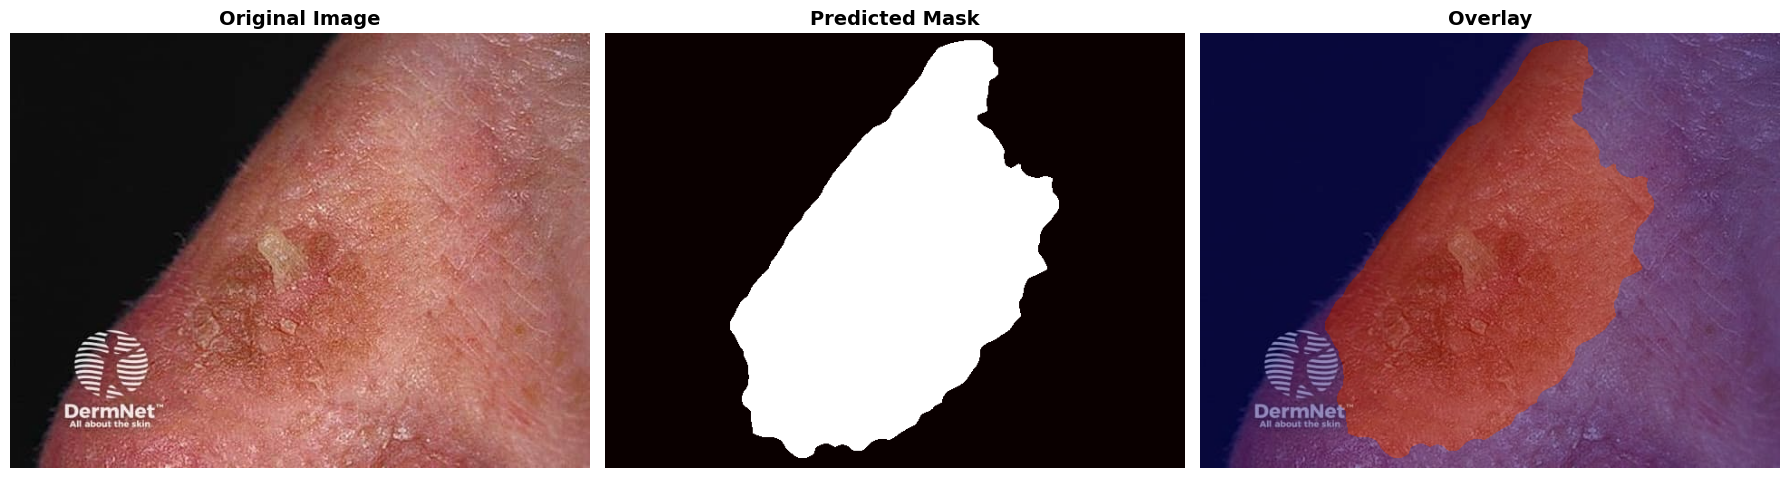


✅ Demo completed!


In [50]:
# ==============================================================================
# CELL 17: TEST SINGLE IMAGE - DEMO
# ==============================================================================

print("\n" + "="*80)
print("🔬 SINGLE IMAGE TEST - DEMO")
print("="*80)

# Lấy 1 ảnh mẫu từ CSV
if os.path.exists(EXTERNAL_CSV):
    df_demo = pd.read_csv(EXTERNAL_CSV)

    if len(df_demo) > 0:
        # Lấy ảnh đầu tiên
        sample_row = df_demo.iloc[0]
        sample_img_name = sample_row['image_name']
        sample_class = sample_row['ground_truth']

        sample_img_path = os.path.join(DATA_TEST_PATH, sample_class, sample_img_name)

        print(f"\n📸 Testing image: {sample_img_name}")
        print(f"   Class: {sample_class}")
        print(f"   Path: {sample_img_path}")

        if os.path.exists(sample_img_path):
            # Tìm ground truth mask (nếu có)
            base_name = os.path.splitext(sample_img_name)[0]
            gt_mask_path = None

            if MASKS_PATH and os.path.exists(MASKS_PATH):
                for ext in ['_mask.png', '_segmentation.png', '.png']:
                    potential_path = os.path.join(MASKS_PATH, base_name + ext)
                    if os.path. exists(potential_path):
                        gt_mask_path = potential_path
                        print(f"   ✅ Ground truth mask found: {os.path.basename(gt_mask_path)}")
                        break

            if gt_mask_path is None:
                print(f"   ⚠️ No ground truth mask found (will only show prediction)")

            # Run prediction
            result = predict_segmentation_single_image(
                image_path=sample_img_path,
                gt_mask_path=gt_mask_path,
                model=hybrid_model,
                apply_preprocessing=False,
                preprocessing_preset='none',
                apply_postprocessing=True,
                postprocessing_preset='noisy',
                save_visualization=True,
                debug=True  # ← Hiển thị kết quả
            )

            print("\n✅ Demo completed!")

        else:
            print(f"❌ Image not found: {sample_img_path}")
    else:
        print("❌ CSV is empty")
else:
    print(f"❌ CSV not found: {EXTERNAL_CSV}")

In [51]:
# ==============================================================================
# CELL 18: COMPARE MODELS - U-NET vs DEEPLAB vs HYBRID
# ==============================================================================

print("\n" + "="*80)
print("🔬 MODEL COMPARISON TEST")
print("="*80)

if os.path.exists(EXTERNAL_CSV):
    df_compare = pd.read_csv(EXTERNAL_CSV)

    # Lấy 10 ảnh mẫu
    n_samples = min(10, len(df_compare))
    sample_indices = np.random.choice(len(df_compare), n_samples, replace=False)

    print(f"\n📊 Testing {n_samples} random images on 3 models...")

    models_to_test = {
        'U-Net': unet_model,
        'DeepLabV3+': deeplab_model,
        'Hybrid': hybrid_model
    }

    comparison_results = []

    for idx in tqdm(sample_indices, desc="Comparing Models"):
        row = df_compare.iloc[idx]
        img_name = row['image_name']
        ground_truth = row['ground_truth']
        img_path = os.path.join(DATA_TEST_PATH, ground_truth, img_name)

        if not os.path.exists(img_path):
            continue

        # Tìm GT mask
        base_name = os.path.splitext(img_name)[0]
        gt_mask_path = None

        if MASKS_PATH and os.path.exists(MASKS_PATH):
            for ext in ['_mask.png', '_segmentation.png', '.png']:
                potential_path = os.path.join(MASKS_PATH, base_name + ext)
                if os.path. exists(potential_path):
                    gt_mask_path = potential_path
                    break

        # Test từng model
        for model_name, model in models_to_test.items():
            try:
                result = predict_segmentation_single_image(
                    image_path=img_path,
                    gt_mask_path=gt_mask_path,
                    model=model,
                    apply_preprocessing=False,
                    apply_postprocessing=True,
                    postprocessing_preset='noisy',
                    save_visualization=False,
                    debug=False
                )

                if result['has_ground_truth']:
                    comparison_results.append({
                        'image_name': img_name,
                        'model': model_name,
                        'iou': result['metrics']['iou'],
                        'dice': result['metrics']['dice'],
                        'f1': result['metrics']['f1']
                    })
            except Exception as e:
                print(f"\n❌ Error with {model_name} on {img_name}: {e}")

    if comparison_results:
        comparison_df = pd.DataFrame(comparison_results)

        print("\n" + "="*80)
        print("📊 MODEL COMPARISON RESULTS")
        print("="*80)

        for model_name in models_to_test. keys():
            model_df = comparison_df[comparison_df['model'] == model_name]
            if len(model_df) > 0:
                print(f"\n{model_name}:")
                print(f"   IoU:   {model_df['iou'].mean():.4f} ± {model_df['iou'].std():.4f}")
                print(f"   Dice: {model_df['dice'].mean():.4f} ± {model_df['dice']. std():.4f}")
                print(f"   F1:   {model_df['f1'].mean():.4f} ± {model_df['f1'].std():.4f}")

        # Visualize comparison
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        metrics_compare = ['iou', 'dice', 'f1']
        titles = ['IoU Comparison', 'Dice Score Comparison', 'F1 Score Comparison']

        for idx, (metric, title) in enumerate(zip(metrics_compare, titles)):
            data_to_plot = [comparison_df[comparison_df['model'] == model][metric]. values
                           for model in models_to_test.keys()]

            axes[idx].boxplot(data_to_plot, labels=models_to_test. keys())
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            axes[idx].set_ylabel('Score', fontsize=10)
            axes[idx].grid(True, alpha=0.3, axis='y')
            axes[idx].set_ylim([0, 1.0])

        plt.tight_layout()
        save_path = os.path.join(RESULTS_FOLDER, 'model_comparison.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✅ Comparison chart saved: {save_path}")
        plt.show()

    else:
        print("\n⚠️ No results with ground truth for comparison")

else:
    print(f"❌ CSV not found: {EXTERNAL_CSV}")


🔬 MODEL COMPARISON TEST

📊 Testing 10 random images on 3 models...


Comparing Models: 100%|██████████| 10/10 [00:28<00:00,  2.81s/it]


⚠️ No results with ground truth for comparison


In [52]:
# ==============================================================================
# CELL 19: TEST WITH DIFFERENT PREPROCESSING STRATEGIES
# ==============================================================================

print("\n" + "="*80)
print("🔬 PREPROCESSING STRATEGY COMPARISON")
print("="*80)

if os.path.exists(EXTERNAL_CSV):
    df_prep = pd.read_csv(EXTERNAL_CSV)

    # Lấy 5 ảnh mẫu
    n_samples = min(5, len(df_prep))
    sample_indices = np.random.choice(len(df_prep), n_samples, replace=False)

    print(f"\n📊 Testing {n_samples} images with different preprocessing...")

    preprocessing_strategies = ['none', 'clinic', 'smartphone_light']

    prep_comparison_results = []

    for idx in tqdm(sample_indices, desc="Testing Preprocessing"):
        row = df_prep.iloc[idx]
        img_name = row['image_name']
        ground_truth = row['ground_truth']
        img_path = os.path.join(DATA_TEST_PATH, ground_truth, img_name)

        if not os.path.exists(img_path):
            continue

        # Tìm GT mask
        base_name = os.path.splitext(img_name)[0]
        gt_mask_path = None

        if MASKS_PATH and os.path.exists(MASKS_PATH):
            for ext in ['_mask.png', '_segmentation.png', '.png']:
                potential_path = os.path.join(MASKS_PATH, base_name + ext)
                if os.path. exists(potential_path):
                    gt_mask_path = potential_path
                    break

        # Test từng preprocessing strategy
        for prep_strategy in preprocessing_strategies:
            try:
                result = predict_segmentation_single_image(
                    image_path=img_path,
                    gt_mask_path=gt_mask_path,
                    model=hybrid_model,
                    apply_preprocessing=(prep_strategy != 'none'),
                    preprocessing_preset=prep_strategy,
                    apply_postprocessing=True,
                    postprocessing_preset='noisy',
                    save_visualization=False,
                    debug=False
                )

                if result['has_ground_truth']:
                    prep_comparison_results.append({
                        'image_name': img_name,
                        'preprocessing':  prep_strategy,
                        'iou': result['metrics']['iou'],
                        'dice':  result['metrics']['dice'],
                        'f1': result['metrics']['f1']
                    })
            except Exception as e:
                print(f"\n❌ Error with {prep_strategy} on {img_name}: {e}")

    if prep_comparison_results:
        prep_df = pd.DataFrame(prep_comparison_results)

        print("\n" + "="*80)
        print("📊 PREPROCESSING COMPARISON RESULTS")
        print("="*80)

        for prep in preprocessing_strategies:
            prep_subset = prep_df[prep_df['preprocessing'] == prep]
            if len(prep_subset) > 0:
                print(f"\n{prep}:")
                print(f"   IoU:   {prep_subset['iou'].mean():.4f} ± {prep_subset['iou'].std():.4f}")
                print(f"   Dice: {prep_subset['dice']. mean():.4f} ± {prep_subset['dice'].std():.4f}")
                print(f"   F1:   {prep_subset['f1']. mean():.4f} ± {prep_subset['f1']. std():.4f}")

        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        metrics_prep = ['iou', 'dice', 'f1']
        titles = ['IoU by Preprocessing', 'Dice by Preprocessing', 'F1 by Preprocessing']

        for idx, (metric, title) in enumerate(zip(metrics_prep, titles)):
            data_to_plot = [prep_df[prep_df['preprocessing'] == prep][metric].values
                           for prep in preprocessing_strategies]

            axes[idx].boxplot(data_to_plot, labels=preprocessing_strategies)
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            axes[idx].set_ylabel('Score', fontsize=10)
            axes[idx].grid(True, alpha=0.3, axis='y')
            axes[idx].set_ylim([0, 1.0])
            axes[idx].tick_params(axis='x', rotation=15)

        plt.tight_layout()
        save_path = os.path.join(RESULTS_FOLDER, 'preprocessing_comparison.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✅ Preprocessing comparison saved: {save_path}")
        plt.show()

    else:
        print("\n⚠️ No results with ground truth for preprocessing comparison")

else:
    print(f"❌ CSV not found: {EXTERNAL_CSV}")


🔬 PREPROCESSING STRATEGY COMPARISON

📊 Testing 5 images with different preprocessing...


Testing Preprocessing: 100%|██████████| 5/5 [00:19<00:00,  3.97s/it]


⚠️ No results with ground truth for preprocessing comparison


In [53]:
# ==============================================================================
# CELL 20: EXPORT SUMMARY REPORT
# ==============================================================================

if 'results_df' in locals() and results_df is not None:

    print("\n" + "="*80)
    print("📄 GENERATING SUMMARY REPORT")
    print("="*80)

    valid_results = results_df[results_df['has_ground_truth'] == True]

    if len(valid_results) > 0:
        # Create summary report
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        report = f"""
{'='*80}
SEGMENTATION TEST SUMMARY REPORT
{'='*80}
Generated: {timestamp}

DATASET INFORMATION
{'='*80}
Total Images Tested:            {len(results_df)}
Images with Ground Truth:      {len(valid_results)}
Data Path:                     {DATA_TEST_PATH}
Masks Path:                    {MASKS_PATH}

OVERALL METRICS
{'='*80}
IoU (Intersection over Union): {valid_results['metric_iou'].mean():.4f} ± {valid_results['metric_iou'].std():.4f}
Dice Score:                     {valid_results['metric_dice'].mean():.4f} ± {valid_results['metric_dice'].std():.4f}
Pixel Accuracy:                {valid_results['metric_pixel_accuracy'].mean():.4f} ± {valid_results['metric_pixel_accuracy'].std():.4f}
Precision:                     {valid_results['metric_precision'].mean():.4f} ± {valid_results['metric_precision'].std():.4f}
Recall:                        {valid_results['metric_recall'].mean():.4f} ± {valid_results['metric_recall']. std():.4f}
F1 Score:                      {valid_results['metric_f1'].mean():.4f} ± {valid_results['metric_f1'].std():.4f}

PIXEL-WISE CONFUSION MATRIX
{'='*80}
True Positive (TP):            {valid_results['metric_tp'].sum():,}
False Positive (FP):           {valid_results['metric_fp'].sum():,}
False Negative (FN):           {valid_results['metric_fn'].sum():,}
True Negative (TN):            {valid_results['metric_tn'].sum():,}

QUALITY DISTRIBUTION (IoU)
{'='*80}
Excellent (≥0.8):              {len(valid_results[valid_results['metric_iou'] >= 0.8])} ({len(valid_results[valid_results['metric_iou'] >= 0.8])/len(valid_results)*100:.1f}%)
Good (0.6-0.8):                {len(valid_results[(valid_results['metric_iou'] >= 0.6) & (valid_results['metric_iou'] < 0.8)])} ({len(valid_results[(valid_results['metric_iou'] >= 0.6) & (valid_results['metric_iou'] < 0.8)])/len(valid_results)*100:.1f}%)
Fair (0.4-0.6):                {len(valid_results[(valid_results['metric_iou'] >= 0.4) & (valid_results['metric_iou'] < 0.6)])} ({len(valid_results[(valid_results['metric_iou'] >= 0.4) & (valid_results['metric_iou'] < 0.6)])/len(valid_results)*100:.1f}%)
Poor (<0.4):                   {len(valid_results[valid_results['metric_iou'] < 0.4])} ({len(valid_results[valid_results['metric_iou'] < 0.4])/len(valid_results)*100:.1f}%)

PER-CLASS METRICS
{'='*80}
"""

        if 'ground_truth' in valid_results.columns:
            for cls in sorted(valid_results['ground_truth'].unique()):
                cls_df = valid_results[valid_results['ground_truth'] == cls]
                report += f"""
{cls}:
  Count:          {len(cls_df)}
  IoU:           {cls_df['metric_iou'].mean():.4f}
  Dice:          {cls_df['metric_dice'].mean():.4f}
  Pixel Acc:     {cls_df['metric_pixel_accuracy'].mean():.4f}
"""

        report += f"""
{'='*80}
CONFIGURATION
{'='*80}
Model:                         Hybrid (U-Net + DeepLabV3+)
Preprocessing:                 {results_df['preprocessing'].mode()[0] if len(results_df) > 0 else 'N/A'}
Postprocessing:                {results_df['postprocessing'].mode()[0] if len(results_df) > 0 else 'N/A'}

FILES GENERATED
{'='*80}
Results CSV:                   segmentation_results_*. csv
Metrics Distribution:          metrics_distribution.png
Per-Class Comparison:          per_class_comparison.png
Confusion Matrix:              confusion_matrix_pixelwise.png

{'='*80}
END OF REPORT
{'='*80}
"""

        # Save report
        report_path = os.path.join(RESULTS_FOLDER, 'segmentation_summary_report.txt')
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write(report)

        print(report)
        print(f"\n✅ Report saved:  {report_path}")

    else:
        print("⚠️ No ground truth available - cannot generate full report")

else:
    print("❌ No results_df found.  Please run Cell 14 first!")


📄 GENERATING SUMMARY REPORT
⚠️ No ground truth available - cannot generate full report


In [58]:
# ==============================================================================
# CELL 21: AUTO EVALUATION - PHÁT HIỆN BỎ SÓT & SAI SÓT
# ==============================================================================

def evaluate_segmentation_quality(pred_mask, gt_mask, threshold=0.5):
    """
    Đánh giá chi tiết chất lượng segmentation

    Returns:
        dict: {
            'quality_level': 'EXCELLENT' | 'GOOD' | 'FAIR' | 'POOR',
            'issues': list of detected issues,
            'recommendations':  list of recommendations
        }
    """
    pred_binary = (pred_mask > threshold).astype(np.uint8)
    gt_binary = (gt_mask > threshold).astype(np.uint8)

    # Calculate metrics
    iou = calculate_iou(pred_mask, gt_mask, threshold)
    dice = calculate_dice(pred_mask, gt_mask, threshold)
    prf = calculate_precision_recall_f1(pred_mask, gt_mask, threshold)

    precision = prf['precision']
    recall = prf['recall']
    tp = prf['tp']
    fp = prf['fp']
    fn = prf['fn']

    issues = []
    recommendations = []

    # ==================================================================
    # 1. ĐÁNH GIÁ TỔNG QUAN (IoU & Dice)
    # ==================================================================
    if iou >= 0.8 and dice >= 0.85:
        quality_level = 'EXCELLENT'
    elif iou >= 0.6 and dice >= 0.7:
        quality_level = 'GOOD'
    elif iou >= 0.4 and dice >= 0.5:
        quality_level = 'FAIR'
    else:
        quality_level = 'POOR'
        issues.append('Overall quality is poor')
        recommendations.append('Consider retraining segmentation model')

    # ==================================================================
    # 2. PHÁT HIỆN BỎ SÓT (False Negative - Under-segmentation)
    # ==================================================================
    # Recall thấp = Bỏ sót nhiều vùng tổn thương
    if recall < 0.6:
        issues.append('⚠️ HIGH FALSE NEGATIVE: Model missed significant lesion areas')
        recommendations.append('→ Model is under-segmenting (bỏ sót tổn thương)')
        recommendations.append('→ Check if preprocessing removes too much detail')
        recommendations.append('→ Consider lowering prediction threshold')

        # Tính tỷ lệ bỏ sót
        total_lesion_pixels = gt_binary.sum()
        missed_pixels = fn
        miss_rate = missed_pixels / total_lesion_pixels if total_lesion_pixels > 0 else 0
        issues.append(f'   Miss Rate: {miss_rate*100:.1f}% of lesion area not detected')

    elif recall < 0.8:
        issues.append('⚠️ MODERATE FALSE NEGATIVE: Some lesion areas missed')
        recommendations.append('→ Consider adjusting segmentation threshold')

    # ==================================================================
    # 3. PHÁT HIỆN DỰ ĐOÁN SAI (False Positive - Over-segmentation)
    # ==================================================================
    # Precision thấp = Dự đoán quá nhiều vùng không phải tổn thương
    if precision < 0.6:
        issues.append('⚠️ HIGH FALSE POSITIVE: Model over-segments (dự đoán thừa)')
        recommendations.append('→ Model is detecting too much non-lesion area')
        recommendations.append('→ Consider increasing prediction threshold')
        recommendations.append('→ Check postprocessing:  may need more aggressive cleaning')

        # Tính tỷ lệ dự đoán sai
        predicted_lesion_pixels = pred_binary.sum()
        false_positive_pixels = fp
        false_positive_rate = false_positive_pixels / predicted_lesion_pixels if predicted_lesion_pixels > 0 else 0
        issues.append(f'   False Positive Rate: {false_positive_rate*100:.1f}% of prediction is wrong')

    elif precision < 0.8:
        issues.append('⚠️ MODERATE FALSE POSITIVE: Some over-segmentation')
        recommendations.append('→ Consider postprocessing adjustments')

    # ==================================================================
    # 4. PHÁT HIỆN MULTIPLE LESIONS (Kiểm tra GT có nhiều vùng không)
    # ==================================================================
    gt_contours, _ = cv2.findContours(gt_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pred_contours, _ = cv2.findContours(pred_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Lọc contours nhỏ (noise)
    gt_contours_filtered = [cnt for cnt in gt_contours if cv2.contourArea(cnt) > 100]
    pred_contours_filtered = [cnt for cnt in pred_contours if cv2.contourArea(cnt) > 100]

    num_gt_lesions = len(gt_contours_filtered)
    num_pred_lesions = len(pred_contours_filtered)

    if num_gt_lesions > 1:
        issues.append(f'⚠️ MULTIPLE LESIONS: Ground truth has {num_gt_lesions} separate lesions')

        if num_pred_lesions < num_gt_lesions:
            issues.append(f'   Model only detected {num_pred_lesions}/{num_gt_lesions} lesions (MISSED LESIONS)')
            recommendations.append('→ Model failed to detect all separate lesions')
            recommendations.append('→ Check if postprocessing "select_largest" is removing valid lesions')
        elif num_pred_lesions > num_gt_lesions:
            issues.append(f'   Model detected {num_pred_lesions} lesions (over-detection)')
            recommendations.append('→ Model may be fragmenting single lesion into multiple regions')

    # ==================================================================
    # 5. PHÁT HIỆN FRAGMENTATION (Vùng dự đoán bị chia nhỏ)
    # ==================================================================
    if num_pred_lesions > num_gt_lesions + 2:  # Quá nhiều fragments
        issues.append(f'⚠️ FRAGMENTATION:  Predicted mask is fragmented into {num_pred_lesions} pieces')
        recommendations.append('→ Postprocessing may need stronger morphological closing')
        recommendations.append('→ Check if "fill_holes" and "smooth_boundary" are enabled')

    # ==================================================================
    # 6. KIỂM TRA COVERAGE (Vùng dự đoán có bao phủ GT không)
    # ==================================================================
    gt_area = gt_binary.sum()
    pred_area = pred_binary.sum()

    if pred_area < gt_area * 0.5:  # Dự đoán quá nhỏ
        issues.append('⚠️ UNDER-SEGMENTATION: Predicted area is too small')
        issues.append(f'   Predicted:  {pred_area} pixels vs GT: {gt_area} pixels')
        recommendations.append('→ Model is being too conservative')

    elif pred_area > gt_area * 2.0:  # Dự đoán quá lớn
        issues.append('⚠️ OVER-SEGMENTATION: Predicted area is too large')
        issues.append(f'   Predicted: {pred_area} pixels vs GT: {gt_area} pixels')
        recommendations. append('→ Model is being too aggressive')

    # ==================================================================
    # 7. KIỂM TRA BOUNDARY ACCURACY (Độ chính xác biên)
    # ==================================================================
    # Tính Hausdorff distance (khoảng cách lớn nhất giữa 2 boundaries)
    from scipy.spatial. distance import directed_hausdorff

    # Extract boundaries
    pred_boundary = cv2.Canny(pred_binary * 255, 50, 150)
    gt_boundary = cv2.Canny(gt_binary * 255, 50, 150)

    pred_points = np.column_stack(np.where(pred_boundary > 0))
    gt_points = np.column_stack(np.where(gt_boundary > 0))

    if len(pred_points) > 0 and len(gt_points) > 0:
        hausdorff_dist = max(
            directed_hausdorff(pred_points, gt_points)[0],
            directed_hausdorff(gt_points, pred_points)[0]
        )

        if hausdorff_dist > 50:  # Boundary error > 50 pixels
            issues. append(f'⚠️ POOR BOUNDARY:  Hausdorff distance = {hausdorff_dist:. 1f} pixels')
            recommendations.append('→ Boundary prediction is inaccurate')
            recommendations.append('→ May need boundary refinement postprocessing')

    # ==================================================================
    # RETURN
    # ==================================================================
    return {
        'quality_level': quality_level,
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall':  recall,
        'num_gt_lesions': num_gt_lesions,
        'num_pred_lesions': num_pred_lesions,
        'issues': issues,
        'recommendations': recommendations
    }


print("✅ evaluate_segmentation_quality defined")

✅ evaluate_segmentation_quality defined


In [59]:
# ==============================================================================
# CELL 22: BATCH AUTO EVALUATION - ĐÁNH GIÁ TỰ ĐỘNG TOÀN BỘ
# ==============================================================================

def batch_auto_evaluation(results_df):
    """
    Đánh giá tự động tất cả các ảnh có ground truth

    Returns:
        evaluation_df: DataFrame with detailed evaluation
    """
    valid_results = results_df[results_df['has_ground_truth'] == True]

    if len(valid_results) == 0:
        print("❌ No ground truth available for auto evaluation")
        return None

    print(f"\n{'='*80}")
    print(f"🤖 AUTO EVALUATION - {len(valid_results)} IMAGES")
    print(f"{'='*80}")

    evaluations = []

    for idx, row in tqdm(valid_results.iterrows(), total=len(valid_results), desc="Evaluating"):
        img_name = row['image_name']
        img_path = row['image_path']
        ground_truth = row. get('ground_truth', 'UNKNOWN')

        # Load predicted mask
        # (Giả sử bạn đã lưu mask trong batch test, hoặc predict lại)
        # Để đơn giản, ta sẽ load từ saved results hoặc re-predict

        # Tìm GT mask
        base_name = os.path.splitext(img_name)[0]
        gt_mask_path = None

        if MASKS_PATH and os.path.exists(MASKS_PATH):
            for ext in ['_mask.png', '_segmentation.png', '. png']:
                potential_path = os.path.join(MASKS_PATH, base_name + ext)
                if os.path.exists(potential_path):
                    gt_mask_path = potential_path
                    break

        if gt_mask_path is None:
            continue

        # Re-predict (hoặc load saved mask)
        try:
            # Load GT
            gt_mask = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)
            gt_mask = gt_mask. astype(np.float32) / 255.0

            # Load predicted mask from row metrics
            # Hoặc re-run prediction
            image = cv2.imread(img_path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Quick predict
            img_tensor = preprocess_for_segmentation(image_rgb).to(device)
            with torch.no_grad():
                mask_pred = hybrid_model(img_tensor).squeeze().cpu().numpy()

            mask_pred_resized = cv2.resize(mask_pred, (gt_mask.shape[1], gt_mask.shape[0]))

            # Postprocessing
            postprocess = get_postprocessing_preset('noisy')
            mask_binary = (mask_pred_resized > 0.5).astype(np.uint8) * 255
            mask_cleaned = remove_small_regions(mask_binary, min_size=500)
            mask_final, _ = postprocess(mask_cleaned, threshold=0.5)
            mask_final_01 = mask_final.astype(np.float32) / 255.0

            # Evaluate
            eval_result = evaluate_segmentation_quality(mask_final_01, gt_mask)

            eval_result['image_name'] = img_name
            eval_result['ground_truth'] = ground_truth
            evaluations.append(eval_result)

        except Exception as e:
            print(f"\n❌ Error evaluating {img_name}: {e}")

    # Create DataFrame
    eval_df = pd.DataFrame(evaluations)

    # Save
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    eval_csv = os.path.join(RESULTS_FOLDER, f'auto_evaluation_{timestamp}.csv')

    # Flatten issues and recommendations
    eval_df['num_issues'] = eval_df['issues'].apply(len)
    eval_df['issues_text'] = eval_df['issues'].apply(lambda x: ' | '.join(x))
    eval_df['recommendations_text'] = eval_df['recommendations'].apply(lambda x: ' | '.join(x))

    eval_df.to_csv(eval_csv, index=False)
    print(f"\n✅ Auto evaluation saved:  {eval_csv}")

    return eval_df


print("✅ batch_auto_evaluation defined")

✅ batch_auto_evaluation defined


In [68]:
# ==============================================================================
# CELL 23: CHẠY AUTO EVALUATION
# ==============================================================================

if 'results_df' in locals() and results_df is not None:

    print("\n🤖 Starting automatic evaluation...")

    eval_df = batch_auto_evaluation(results_df)

    if eval_df is not None and len(eval_df) > 0:

        print(f"\n{'='*80}")
        print(f"📊 AUTO EVALUATION SUMMARY")
        print(f"{'='*80}")

        # Quality distribution
        print(f"\n📊 Quality Distribution:")
        quality_counts = eval_df['quality_level'].value_counts()
        for level in ['EXCELLENT', 'GOOD', 'FAIR', 'POOR']:
            count = quality_counts. get(level, 0)
            print(f"   {level:12s}: {count:3d} ({count/len(eval_df)*100:5.1f}%)")

        # Images with issues
        images_with_issues = eval_df[eval_df['num_issues'] > 0]
        print(f"\n⚠️ Images with Issues: {len(images_with_issues)}/{len(eval_df)}")

        if len(images_with_issues) > 0:
            print(f"\n🔍 Most Common Issues:")
            all_issues = []
            for issues_list in images_with_issues['issues']:
                all_issues.extend(issues_list)

            issue_counts = Counter(all_issues)
            for issue, count in issue_counts.most_common(10):
                print(f"   [{count: 3d}x] {issue}")

        # Per-class analysis
        if 'ground_truth' in eval_df. columns:
            print(f"\n{'='*80}")
            print(f"📊 PER-CLASS QUALITY")
            print(f"{'='*80}")

            for cls in sorted(eval_df['ground_truth'].unique()):
                cls_df = eval_df[eval_df['ground_truth'] == cls]

                excellent = len(cls_df[cls_df['quality_level'] == 'EXCELLENT'])
                good = len(cls_df[cls_df['quality_level'] == 'GOOD'])
                fair = len(cls_df[cls_df['quality_level'] == 'FAIR'])
                poor = len(cls_df[cls_df['quality_level'] == 'POOR'])

                avg_iou = cls_df['iou'].mean()
                avg_recall = cls_df['recall'].mean()

                print(f"\n{cls}:")
                print(f"   Total: {len(cls_df)}")
                print(f"   Quality: E={excellent} G={good} F={fair} P={poor}")
                print(f"   Avg IoU: {avg_iou:.3f}")
                print(f"   Avg Recall: {avg_recall:.3f} {'⚠️ LOW' if avg_recall < 0.7 else '✅'}")

        # Worst cases (bỏ sót nhiều)
        print(f"\n{'='*80}")
        print(f"❌ TOP 10 WORST CASES (Highest Miss Rate)")
        print(f"{'='*80}")

        worst_cases = eval_df.nsmallest(10, 'recall')[['image_name', 'ground_truth', 'recall', 'quality_level', 'num_issues']]
        print(worst_cases. to_string(index=False))

        # Cases with multiple lesions
        multi_lesion = eval_df[eval_df['num_gt_lesions'] > 1]
        if len(multi_lesion) > 0:
            print(f"\n{'='*80}")
            print(f"🔍 MULTIPLE LESION CASES ({len(multi_lesion)} images)")
            print(f"{'='*80}")

            for idx, row in multi_lesion.iterrows():
                print(f"\n{row['image_name']}:")
                print(f"   GT Lesions: {row['num_gt_lesions']}")
                print(f"   Predicted:  {row['num_pred_lesions']}")
                print(f"   Quality: {row['quality_level']}")
                if row['num_pred_lesions'] < row['num_gt_lesions']:
                    print(f"   ❌ MISSED {row['num_gt_lesions'] - row['num_pred_lesions']} LESION(S)")

        print(f"\n{'='*80}")
        print(f"✅ AUTO EVALUATION COMPLETE")
        print(f"{'='*80}")

else:
    print("❌ No results_df found.  Please run Cell 14 first!")


🤖 Starting automatic evaluation...
❌ No ground truth available for auto evaluation


In [61]:
# ==============================================================================
# CELL 24: VISUALIZE AUTO EVALUATION RESULTS
# ==============================================================================

if 'eval_df' in locals() and eval_df is not None:

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Quality distribution
    quality_counts = eval_df['quality_level'].value_counts()
    quality_order = ['EXCELLENT', 'GOOD', 'FAIR', 'POOR']
    quality_counts_ordered = [quality_counts.get(level, 0) for level in quality_order]
    colors = ['green', 'lightgreen', 'orange', 'red']

    axes[0, 0]. bar(quality_order, quality_counts_ordered, color=colors, edgecolor='black')
    axes[0, 0].set_title('Quality Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Count', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # 2. Recall distribution (phát hiện bỏ sót)
    axes[0, 1].hist(eval_df['recall'], bins=20, color='steelblue', edgecolor='black')
    axes[0, 1].axvline(0.7, color='red', linestyle='--', linewidth=2, label='Threshold (0.7)')
    axes[0, 1].set_title('Recall Distribution (Miss Rate)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Recall', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Precision vs Recall scatter
    axes[1, 0].scatter(eval_df['recall'], eval_df['precision'],
                      c=eval_df['iou'], cmap='RdYlGn', s=100, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Recall (1 - Miss Rate)', fontsize=12)
    axes[1, 0].set_ylabel('Precision', fontsize=12)
    axes[1, 0].set_title('Precision vs Recall (colored by IoU)', fontsize=14, fontweight='bold')
    axes[1, 0].axvline(0.7, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].axhline(0.7, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
    cbar.set_label('IoU', fontsize=10)

    # 4. Issues per image
    axes[1, 1].hist(eval_df['num_issues'], bins=range(0, eval_df['num_issues'].max()+2),
                   color='coral', edgecolor='black', align='left')
    axes[1, 1].set_title('Number of Issues per Image', fontsize=14, fontweight='bold')
    axes[1, 1]. set_xlabel('Number of Issues', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    save_path = os.path.join(RESULTS_FOLDER, 'auto_evaluation_summary.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Auto evaluation visualization saved: {save_path}")
    plt.show()

else:
    print("❌ No eval_df found. Please run Cell 23 first!")

❌ No eval_df found. Please run Cell 23 first!


In [62]:
# ==============================================================================
# CELL 25: EXPORT PROBLEM CASES (BỎ SÓT & SAI SÓT)
# ==============================================================================

if 'eval_df' in locals() and eval_df is not None:

    print(f"\n{'='*80}")
    print(f"📄 EXPORTING PROBLEM CASES")
    print(f"{'='*80}")

    # 1. Cases với recall thấp (bỏ sót nhiều)
    high_miss_rate = eval_df[eval_df['recall'] < 0.7]

    if len(high_miss_rate) > 0:
        miss_csv = os.path.join(RESULTS_FOLDER, 'high_miss_rate_cases.csv')
        high_miss_rate.to_csv(miss_csv, index=False)
        print(f"\n⚠️ High Miss Rate Cases: {len(high_miss_rate)}")
        print(f"   Saved to: {miss_csv}")
        print(f"\n   Top 5 worst:")
        print(high_miss_rate.nsmallest(5, 'recall')[['image_name', 'recall', 'quality_level']].to_string(index=False))

    # 2. Cases với precision thấp (dự đoán sai nhiều)
    high_false_positive = eval_df[eval_df['precision'] < 0.7]

    if len(high_false_positive) > 0:
        fp_csv = os.path.join(RESULTS_FOLDER, 'high_false_positive_cases.csv')
        high_false_positive.to_csv(fp_csv, index=False)
        print(f"\n⚠️ High False Positive Cases: {len(high_false_positive)}")
        print(f"   Saved to: {fp_csv}")
        print(f"\n   Top 5 worst:")
        print(high_false_positive.nsmallest(5, 'precision')[['image_name', 'precision', 'quality_level']].to_string(index=False))

    # 3. Multiple lesions cases
    multi_lesion_cases = eval_df[eval_df['num_gt_lesions'] > 1]

    if len(multi_lesion_cases) > 0:
        multi_csv = os.path.join(RESULTS_FOLDER, 'multiple_lesion_cases.csv')
        multi_lesion_cases.to_csv(multi_csv, index=False)
        print(f"\n⚠️ Multiple Lesion Cases: {len(multi_lesion_cases)}")
        print(f"   Saved to: {multi_csv}")

    # 4. All problem cases (POOR quality)
    poor_cases = eval_df[eval_df['quality_level'] == 'POOR']

    if len(poor_cases) > 0:
        poor_csv = os.path.join(RESULTS_FOLDER, 'poor_quality_cases.csv')
        poor_cases.to_csv(poor_csv, index=False)
        print(f"\n❌ Poor Quality Cases: {len(poor_cases)}")
        print(f"   Saved to: {poor_csv}")

    print(f"\n{'='*80}")
    print(f"✅ PROBLEM CASES EXPORTED")
    print(f"{'='*80}")

else:
    print("❌ No eval_df found. Please run Cell 23 first!")

❌ No eval_df found. Please run Cell 23 first!


In [63]:
# ==============================================================================
# CELL 26: AUTO EVALUATION - KHÔNG CẦN GROUND TRUTH (HEURISTIC)
# ==============================================================================

def evaluate_mask_quality_heuristic(mask, image_shape):
    """
    Đánh giá chất lượng mask KHÔNG cần ground truth
    Dựa trên các heuristics (quy tắc kinh nghiệm)

    Args:
        mask:  Predicted mask (H, W) in [0, 1]
        image_shape: (H, W) của ảnh gốc

    Returns:
        dict: Evaluation results
    """
    h, w = image_shape
    total_pixels = h * w

    mask_binary = (mask > 0.5).astype(np.uint8)
    mask_area = mask_binary.sum()

    issues = []
    warnings = []
    recommendations = []

    # ==================================================================
    # 1. COVERAGE CHECK (Tỷ lệ vùng phân đoạn)
    # ==================================================================
    coverage = mask_area / total_pixels

    if coverage < 0.01:  # Quá nhỏ (<1%)
        issues.append('⚠️ VERY SMALL MASK:  Coverage < 1%')
        issues.append(f'   Mask area: {mask_area} pixels ({coverage*100:.2f}%)')
        recommendations.append('→ Model may have failed to detect lesion')
        recommendations.append('→ Check if image quality is too poor')
        quality_coverage = 'POOR'
    elif coverage < 0.05:  # Nhỏ (1-5%)
        warnings.append('⚠️ Small mask: Coverage < 5%')
        quality_coverage = 'FAIR'
    elif coverage > 0.6:  # Quá lớn (>60%)
        issues.append('⚠️ VERY LARGE MASK: Coverage > 60%')
        issues.append(f'   Mask area:  {mask_area} pixels ({coverage*100:.2f}%)')
        recommendations.append('→ Model may be over-segmenting')
        recommendations.append('→ Check if background is being included')
        quality_coverage = 'POOR'
    elif coverage > 0.4:  # Lớn (40-60%)
        warnings.append('⚠️ Large mask: Coverage > 40%')
        quality_coverage = 'FAIR'
    else:
        quality_coverage = 'GOOD'

    # ==================================================================
    # 2. FRAGMENTATION CHECK (Mask có bị vỡ mảnh không)
    # ==================================================================
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Lọc contours nhỏ (noise)
    significant_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]
    num_regions = len(significant_contours)

    if num_regions == 0:
        issues.append('❌ NO LESION DETECTED')
        quality_fragmentation = 'POOR'
    elif num_regions == 1:
        quality_fragmentation = 'EXCELLENT'
    elif num_regions == 2:
        warnings.append('⚠️ Two separate regions detected (possible multiple lesions)')
        quality_fragmentation = 'GOOD'
    elif num_regions <= 5:
        issues.append(f'⚠️ FRAGMENTATION: {num_regions} separate regions')
        recommendations.append('→ Mask is fragmented - may need better postprocessing')
        quality_fragmentation = 'FAIR'
    else:
        issues.append(f'❌ SEVERE FRAGMENTATION: {num_regions} separate regions')
        recommendations.append('→ Mask is heavily fragmented')
        recommendations.append('→ Check preprocessing and postprocessing settings')
        quality_fragmentation = 'POOR'

    # ==================================================================
    # 3. SOLIDITY CHECK (Độ compact của vùng lớn nhất)
    # ==================================================================
    if len(significant_contours) > 0:
        largest_contour = max(significant_contours, key=cv2.contourArea)
        largest_area = cv2.contourArea(largest_contour)

        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)

        solidity = largest_area / hull_area if hull_area > 0 else 0

        if solidity < 0.5:
            issues.append(f'⚠️ NON-COMPACT SHAPE: Solidity = {solidity:.2f}')
            issues.append('   Possible overlapping or irregular lesions')
            recommendations.append('→ May indicate multiple overlapping lesions')
            quality_solidity = 'POOR'
        elif solidity < 0.7:
            warnings.append(f'⚠️ Irregular shape: Solidity = {solidity:.2f}')
            quality_solidity = 'FAIR'
        elif solidity < 0.85:
            quality_solidity = 'GOOD'
        else:
            quality_solidity = 'EXCELLENT'
    else:
        solidity = 0
        quality_solidity = 'POOR'

    # ==================================================================
    # 4. BOUNDARY SMOOTHNESS (Độ mịn của biên)
    # ==================================================================
    if len(significant_contours) > 0:
        largest_contour = max(significant_contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(largest_contour, True)
        area = cv2.contourArea(largest_contour)

        # Circularity:  4π×area / perimeter²
        # Circle = 1, more irregular = smaller
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
        else:
            circularity = 0

        if circularity < 0.3:
            warnings.append(f'⚠️ Very irregular boundary: Circularity = {circularity:.2f}')
            quality_boundary = 'FAIR'
        elif circularity < 0.5:
            quality_boundary = 'GOOD'
        else:
            quality_boundary = 'EXCELLENT'
    else:
        circularity = 0
        quality_boundary = 'POOR'

    # ==================================================================
    # 5. POSITION CHECK (Vị trí vùng phân đoạn)
    # ==================================================================
    if len(significant_contours) > 0:
        largest_contour = max(significant_contours, key=cv2.contourArea)
        M = cv2.moments(largest_contour)

        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])

            # Kiểm tra có quá gần biên không
            margin_x = min(cx, w - cx)
            margin_y = min(cy, h - cy)

            min_margin = min(margin_x, margin_y)
            margin_ratio = min_margin / min(w, h)

            if margin_ratio < 0.05:  # Quá gần biên (<5% kích thước ảnh)
                warnings.append(f'⚠️ Lesion too close to image border')
                warnings.append(f'   May be cropped - recommendation: re-capture with better framing')
        else:
            cx, cy = 0, 0
    else:
        cx, cy = 0, 0

    # ==================================================================
    # 6. CONFIDENCE SCORE (Độ tin cậy trung bình của mask)
    # ==================================================================
    mask_confidence = mask[mask > 0.5]. mean() if mask_area > 0 else 0

    if mask_confidence < 0.6:
        warnings.append(f'⚠️ Low prediction confidence: {mask_confidence:.2f}')
        recommendations.append('→ Model is uncertain about this segmentation')

    # ==================================================================
    # 7. OVERALL QUALITY ASSESSMENT
    # ==================================================================
    quality_scores = {
        'EXCELLENT': 4,
        'GOOD': 3,
        'FAIR':  2,
        'POOR': 1
    }

    scores = [
        quality_scores.get(quality_coverage, 1),
        quality_scores.get(quality_fragmentation, 1),
        quality_scores.get(quality_solidity, 1),
        quality_scores.get(quality_boundary, 1)
    ]

    avg_score = np.mean(scores)

    if avg_score >= 3.5:
        overall_quality = 'EXCELLENT'
    elif avg_score >= 2.5:
        overall_quality = 'GOOD'
    elif avg_score >= 1.5:
        overall_quality = 'FAIR'
    else:
        overall_quality = 'POOR'

    # ==================================================================
    # RETURN
    # ==================================================================
    return {
        'overall_quality': overall_quality,
        'coverage': coverage,
        'num_regions': num_regions,
        'solidity': solidity,
        'circularity': circularity,
        'mask_confidence': mask_confidence,
        'centroid':  (cx, cy),
        'quality_coverage': quality_coverage,
        'quality_fragmentation': quality_fragmentation,
        'quality_solidity': quality_solidity,
        'quality_boundary': quality_boundary,
        'issues': issues,
        'warnings':  warnings,
        'recommendations': recommendations
    }


print("✅ evaluate_mask_quality_heuristic defined")

✅ evaluate_mask_quality_heuristic defined


In [64]:
# ==============================================================================
# CELL 27: BATCH HEURISTIC EVALUATION
# ==============================================================================

def batch_heuristic_evaluation(results_df):
    """
    Đánh giá heuristic cho tất cả các ảnh (KHÔNG cần ground truth)
    """
    print(f"\n{'='*80}")
    print(f"🤖 HEURISTIC EVALUATION (No GT needed) - {len(results_df)} IMAGES")
    print(f"{'='*80}")

    evaluations = []

    for idx, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Evaluating"):
        img_name = row['image_name']
        img_path = row['image_path']
        ground_truth = row. get('ground_truth', 'UNKNOWN')

        try:
            # Load image
            image = cv2.imread(img_path)
            if image is None:
                continue

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_shape = image_rgb.shape[:2]

            # Predict mask
            img_tensor = preprocess_for_segmentation(image_rgb).to(device)
            with torch.no_grad():
                mask_pred = hybrid_model(img_tensor).squeeze().cpu().numpy()

            mask_pred_resized = cv2.resize(mask_pred, (image_shape[1], image_shape[0]))

            # Postprocessing
            postprocess = get_postprocessing_preset('noisy')
            mask_binary = (mask_pred_resized > 0.5).astype(np.uint8) * 255
            mask_cleaned = remove_small_regions(mask_binary, min_size=500)
            mask_final, _ = postprocess(mask_cleaned, threshold=0.5)
            mask_final_01 = mask_final. astype(np.float32) / 255.0

            # Heuristic evaluation
            eval_result = evaluate_mask_quality_heuristic(mask_final_01, image_shape)

            eval_result['image_name'] = img_name
            eval_result['ground_truth'] = ground_truth
            evaluations.append(eval_result)

        except Exception as e:
            print(f"\n❌ Error evaluating {img_name}: {e}")

    # Create DataFrame
    eval_df = pd.DataFrame(evaluations)

    # Save
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    eval_csv = os.path.join(RESULTS_FOLDER, f'heuristic_evaluation_{timestamp}.csv')

    # Flatten issues/warnings
    eval_df['num_issues'] = eval_df['issues'].apply(len)
    eval_df['num_warnings'] = eval_df['warnings'].apply(len)
    eval_df['issues_text'] = eval_df['issues']. apply(lambda x: ' | '.join(x))
    eval_df['warnings_text'] = eval_df['warnings'].apply(lambda x: ' | '.join(x))
    eval_df['recommendations_text'] = eval_df['recommendations'].apply(lambda x: ' | '.join(x))

    eval_df.to_csv(eval_csv, index=False)
    print(f"\n✅ Heuristic evaluation saved:  {eval_csv}")

    return eval_df


print("✅ batch_heuristic_evaluation defined")

✅ batch_heuristic_evaluation defined


In [71]:
# ==============================================================================
# CELL 28: CHẠY HEURISTIC EVALUATION
# ==============================================================================

if 'results_df' in locals() and results_df is not None:

    print("\n🤖 Starting heuristic evaluation (no GT needed)...")

    eval_heuristic_df = batch_heuristic_evaluation(results_df)

    if eval_heuristic_df is not None and len(eval_heuristic_df) > 0:

        print(f"\n{'='*80}")
        print(f"📊 HEURISTIC EVALUATION SUMMARY")
        print(f"{'='*80}")

        # Quality distribution
        print(f"\n📊 Quality Distribution:")
        quality_counts = eval_heuristic_df['overall_quality'].value_counts()
        for level in ['EXCELLENT', 'GOOD', 'FAIR', 'POOR']:
            count = quality_counts. get(level, 0)
            print(f"   {level:12s}: {count:3d} ({count/len(eval_heuristic_df)*100:5.1f}%)")

        # Images with issues
        images_with_issues = eval_heuristic_df[eval_heuristic_df['num_issues'] > 0]
        print(f"\n⚠️ Images with Issues: {len(images_with_issues)}/{len(eval_heuristic_df)}")

        if len(images_with_issues) > 0:
            print(f"\n🔍 Most Common Issues:")
            all_issues = []
            for issues_list in images_with_issues['issues']:
                all_issues.extend(issues_list)

            issue_counts = Counter(all_issues)
            for issue, count in issue_counts.most_common(10):
                print(f"   [{count:3d}x] {issue}")

        # Fragmentation cases
        fragmented = eval_heuristic_df[eval_heuristic_df['num_regions'] > 2]
        print(f"\n⚠️ Fragmented Masks (>2 regions): {len(fragmented)}")

        if len(fragmented) > 0:
            print(f"\n   Top 5 most fragmented:")
            worst_frag = fragmented.nlargest(5, 'num_regions')[['image_name', 'num_regions', 'overall_quality']]
            print(worst_frag. to_string(index=False))

        # Very small masks (possible missed detection)
        very_small = eval_heuristic_df[eval_heuristic_df['coverage'] < 0.01]
        print(f"\n❌ Very Small Masks (<1% coverage): {len(very_small)}")

        if len(very_small) > 0:
            print(f"   Possible missed detections:")
            print(very_small[['image_name', 'coverage', 'overall_quality']].to_string(index=False))

        # Very large masks (possible over-segmentation)
        very_large = eval_heuristic_df[eval_heuristic_df['coverage'] > 0.6]
        print(f"\n⚠️ Very Large Masks (>60% coverage): {len(very_large)}")

        if len(very_large) > 0:
            print(f"   Possible over-segmentation:")
            print(very_large[['image_name', 'coverage', 'overall_quality']].to_string(index=False))

        # Per-class analysis
        if 'ground_truth' in eval_heuristic_df.columns:
            print(f"\n{'='*80}")
            print(f"📊 PER-CLASS QUALITY")
            print(f"{'='*80}")

            for cls in sorted(eval_heuristic_df['ground_truth'].unique()):
                cls_df = eval_heuristic_df[eval_heuristic_df['ground_truth'] == cls]

                excellent = len(cls_df[cls_df['overall_quality'] == 'EXCELLENT'])
                good = len(cls_df[cls_df['overall_quality'] == 'GOOD'])
                fair = len(cls_df[cls_df['overall_quality'] == 'FAIR'])
                poor = len(cls_df[cls_df['overall_quality'] == 'POOR'])

                avg_coverage = cls_df['coverage'].mean()
                avg_solidity = cls_df['solidity'].mean()

                print(f"\n{cls}:")
                print(f"   Total: {len(cls_df)}")
                print(f"   Quality: E={excellent} G={good} F={fair} P={poor}")
                print(f"   Avg Coverage: {avg_coverage:.3f}")
                print(f"   Avg Solidity: {avg_solidity:.3f}")

        print(f"\n{'='*80}")
        print(f"✅ HEURISTIC EVALUATION COMPLETE")
        print(f"{'='*80}")

else:
    print("❌ No results_df found.  Please run Cell 14 first!")


🤖 Starting heuristic evaluation (no GT needed)...

🤖 HEURISTIC EVALUATION (No GT needed) - 158 IMAGES


Evaluating: 100%|██████████| 158/158 [02:30<00:00,  1.05it/s]


✅ Heuristic evaluation saved:  d:/DoAn_DaLieu/8_Segmentation_Test/results/heuristic_evaluation_20260102_172138.csv

📊 HEURISTIC EVALUATION SUMMARY

📊 Quality Distribution:
   EXCELLENT   : 126 ( 79.7%)
   GOOD        :  31 ( 19.6%)
   FAIR        :   0 (  0.0%)
   POOR        :   1 (  0.6%)

⚠️ Images with Issues: 26/158

🔍 Most Common Issues:
   [ 25x] ⚠️ VERY LARGE MASK: Coverage > 60%
   [  1x]    Mask area:  232854 pixels (75.80%)
   [  1x]    Mask area:  235718 pixels (76.73%)
   [  1x]    Mask area:  269521 pixels (87.73%)
   [  1x]    Mask area:  300550 pixels (97.84%)
   [  1x]    Mask area:  265861 pixels (86.54%)
   [  1x]    Mask area:  293875 pixels (95.66%)
   [  1x]    Mask area:  286503 pixels (93.26%)
   [  1x]    Mask area:  216800 pixels (70.57%)
   [  1x] ⚠️ VERY SMALL MASK:  Coverage < 1%

⚠️ Fragmented Masks (>2 regions): 0

❌ Very Small Masks (<1% coverage): 1
   Possible missed detections:
image_name  coverage overall_quality
  1103.jpg       0.0            POOR

In [70]:
# ==============================================================================
# CELL 30: CLASS-SPECIFIC THRESHOLD TUNING
# ==============================================================================

# Threshold động theo class
CLASS_THRESHOLDS = {
    'VASC': 0.6,   # Tăng threshold để giảm over-segmentation
    'AKIEC': 0.55,  # Tăng nhẹ
    'BCC': 0.45,   # Giảm để tránh missed detection (như 1103.jpg)
    'NV': 0.5,     # Giữ nguyên (đã rất tốt)
    'MEL': 0.5,
    'DF': 0.5,
    'BKL': 0.5
}

def predict_with_adaptive_threshold(image_path, ground_truth_class, model=hybrid_model):
    """Predict với threshold động theo class"""

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Predict
    img_tensor = preprocess_for_segmentation(image_rgb).to(device)
    with torch.no_grad():
        mask_pred = model(img_tensor).squeeze().cpu().numpy()

    # Resize
    mask_resized = cv2.resize(mask_pred, (image_rgb.shape[1], image_rgb.shape[0]))

    # Áp dụng threshold động
    threshold = CLASS_THRESHOLDS. get(ground_truth_class, 0.5)
    mask_binary = (mask_resized > threshold).astype(np.uint8) * 255

    # Postprocessing
    mask_cleaned = remove_small_regions(mask_binary, min_size=500)
    postprocess = get_postprocessing_preset('noisy')
    mask_final, _ = postprocess(mask_cleaned, threshold=threshold)

    return mask_final. astype(np.float32) / 255.0


print("✅ Adaptive threshold function defined")

✅ Adaptive threshold function defined
